# Analyse multivariée entre groupe de gènes (microcine, virulence, résistance)

In [1]:
#!pip install prince

In [2]:
#!pip install adjustText

In [3]:
#!pip install scikit-bio

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import prince
from adjustText import adjust_text
from sklearn.metrics import pairwise_distances
import networkx as nx
import matplotlib.patches as patches
import seaborn as sns
import numpy as np
from skbio.stats.distance import mantel
from scipy.spatial import procrustes
from scipy.spatial import ConvexHull
from adjustText import adjust_text

In [5]:
df = pd.read_excel("../data/Features_souches/jointures.xlsx")

In [6]:
df.shape

(34, 4810)

In [7]:
# Vérifions si le jeu de données contient des valeurs manquantes
nb_obs_manquantes = df.isnull().any(axis=1).sum()

print(f"Nombre d'observations avec au moins une valeur manquante : {nb_obs_manquantes}")

Nombre d'observations avec au moins une valeur manquante : 0


In [8]:
# Definition d'un jeu de données avec seulement les gènes
cols = [col for col in df.columns if col.startswith("FT")]

X = df[cols]

X.shape

(34, 4422)

In [9]:
# Dataframe de gènes
df = df.drop(columns=cols)

df.shape

(34, 388)

### Exploration et traitement des données

In [10]:
# Vérification de la variabilité des gènes
variabilite = df.nunique()
genes_constants = variabilite[variabilite == 1].index.tolist()
genes_variables = variabilite[variabilite > 1].index.tolist()

print(f"Nombre de gènes constants (pas de variabilité) : {len(genes_constants)}")
print(f"Nombre de gènes variables : {len(genes_variables)}")

Nombre de gènes constants (pas de variabilité) : 121
Nombre de gènes variables : 267


In [11]:
# Vérifions la valeur constante (0 ou 1) des gènes
valeurs_constants = {g: df[g].unique()[0] for g in genes_constants}

# Comptage des gènes constants à 0 et à 1
nb_constants_0 = sum(v == 0 for v in valeurs_constants.values())
nb_constants_1 = sum(v == 1 for v in valeurs_constants.values())

print(f"Nombre total de gènes constants : {len(genes_constants)}")
print(f" - constants à 0 : {nb_constants_0}")
print(f" - constants à 1 : {nb_constants_1}")

Nombre total de gènes constants : 121
 - constants à 0 : 121
 - constants à 1 : 0


In [12]:
# Nombre de colonnes constantes
cstes = variabilite == 1
cols_cstes = cstes[cstes].index.tolist()

# Suppression des colonnes constantes
df = df.drop(columns=cols_cstes)

df.shape

(34, 267)

In [13]:
# Sélection des gènes présents dans une seule souche (somme = 1)
genes_uniquement_une = df.columns[df.sum(axis=0) == 1].tolist()

print(f"Nombre de gènes présents dans une seule souche : {len(genes_uniquement_une)}")
print("Gènes :", genes_uniquement_une)

Nombre de gènes présents dans une seule souche : 25
Gènes : ['ENA.AAA23540.AAA23540.1 Escherichia coli hypothetical protein', 'ENA.AAA23589.AAA23589.1 Plasmid ColBM-Cl139 hypothetical protein', 'ENA.AAA98156.AAA98156.1 Plasmid pKY1 hypothetical protein', 'ENA.AAA98157.AAA98157.1 Plasmid pKY1 immunity protein', 'ENA.AAC16352.AAC16352.1 Escherichia coli microcin V immunity protein', 'ENA.AAC16353.AAC16353.1 Escherichia coli microcin V bacteriocin', 'ENA.CAJ44959.CAJ44959.1 Escherichia coli MchF protein', 'espR3', 'espR4', 'espX2', 'espX6', 'faeC', 'faeD', 'faeI', 'faeJ', 'ibeA', 'kpsT', 'sfaX', 'AAC.3..IId', 'MCR.1', 'QnrS1', 'TEM.208', 'dfrA5', 'dfrA8', 'ramA']


In [14]:
df = df.drop(columns=genes_uniquement_une)

In [15]:
# Exploration du nombre de variables et observations
nb_obs, nb_total = df.shape

binaires = [c for c in df.columns if set(df[c].unique()) <= {0, 1}]
nb_binaires = len(binaires)
nb_non_binaires = nb_total - nb_binaires

print(f"Nombre d'observations : {nb_obs}")
print(f"Nombre de variables   : {nb_total}")
print(f"Nombre de variables binaires : {nb_binaires}")
print(f"Nombre de variables non binaires : {nb_non_binaires}")

Nombre d'observations : 34
Nombre de variables   : 242
Nombre de variables binaires : 241
Nombre de variables non binaires : 1


In [16]:
df.head()

,Souche,ENA.AAA23080.AAA23080.1 Plasmid ColE6-CT14 hypothetical protein,ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein,ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein,ENA.AAA23188.AAA23188.1 Plasmid ColIb hypothetical protein,ENA.AAA23189.AAA23189.1 Plasmid ColIb hypothetical protein,ENA.AAA23594.AAA23594.1 Plasmid ColBM-Cl139 hypothetical protein,ENA.AAB61768.AAB61768.1 Escherichia coli ferrichrome-iron receptor,ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein,ENA.AAC16351.AAC16351.1 Escherichia coli microcin V bacteriocin,...,pmrF,qacH,sul1,sul2,sul3,tet.A.,tet.B.,tolC,ugd,yojI
0,958,1,0,0,0,0,0,1,0,0,...,1,0,0,1,0,0,0,1,1,1
1,982,1,0,0,0,0,0,1,0,0,...,1,0,1,1,0,1,0,1,1,1
2,984,0,0,0,0,0,1,1,0,0,...,1,0,0,1,0,0,0,1,1,1
3,985,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,1,1
4,986,0,0,0,0,0,0,1,0,0,...,1,0,0,1,0,0,1,1,1,1


### Catégorisation des gènes

In [17]:
cols = df.columns.tolist()
#print(cols)

In [18]:
raw_bacteriocine = """
ENA.CAA40814.CAA40814.1 Escherichia coli hypothetical protein
ENA.AAA23540.AAA23540.1 Escherichia coli hypothetical protein
ENA.CAA30724.CAA30724.1 Escherichia coli hypothetical protein
ENA.AAA23080.AAA23080.1 Plasmid ColE6-CT14 hypothetical protein
ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein
ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein
ENA.AAA23188.AAA23188.1 Plasmid ColIb hypothetical protein
ENA.AAA23189.AAA23189.1 Plasmid ColIb hypothetical protein
ENA.AAA23589.AAA23589.1 Plasmid ColBM-Cl139 hypothetical protein
ENA.AAA23594.AAA23594.1 Plasmid ColBM-Cl139 hypothetical protein
ENA.AAA98156.AAA98156.1 Plasmid pKY1 hypothetical protein
ENA.AAA98157.AAA98157.1 Plasmid pKY1 immunity protein
ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein
ENA.AAC16351.AAC16351.1 Escherichia coli microcin V bacteriocin
ENA.AAC16352.AAC16352.1 Escherichia coli microcin V immunity protein
ENA.AAC16353.AAC16353.1 Escherichia coli microcin V bacteriocin
ENA.AAD28494.AAD28494.1 Escherichia coli microcin J25 precursor
ENA.AAD28495.AAD28495.1 Escherichia coli McjB
ENA.AAD28497.AAD28497.1 Escherichia coli McjD
ENA.CAA33859.CAA33859.1 Plasmid ColE5-099 partial colicin E5 (1 is 2nd base in codon)
ENA.CAA33860.CAA33860.1 Plasmid ColE5-099 immunity protein (AA 1-83)
ENA.CAA40743.CAA40743.1 Escherichia coli cvaA protein
ENA.CAA40744.CAA40744.1 Escherichia coli cvaB protein
ENA.CAJ40934.CAJ40934.1 Escherichia coli microcin J25 processing protein
ENA.CAJ44958.CAJ44958.1 Escherichia coli MchE protein
ENA.CAJ44959.CAJ44959.1 Escherichia coli MchF protein
""".strip()

raw_resistance = """
AAC.3..IId
AAC.3..IV
ANT.3....IIa
APH.3....Ib
APH.3...Ia
APH.4..Ia
APH.6..Id
CTX.M.1
CTX.M.55
Escherichia_coli_acrA
Escherichia_coli_ampC
Escherichia_coli_ampC1_beta.lactamase
Escherichia_coli_ampH
Escherichia_coli_emrE
Escherichia_coli_mdfA
MCR.1
QnrB5
QnrS1
SAT.1
TEM.1
TEM.208
aadA2
aadA5
acrB
acrD
acrE
acrF
acrS
bacA
baeR
baeS
cmlA1
cpxA
dfrA1
dfrA12
dfrA14
dfrA17
dfrA5
dfrA8
emrA
emrB
emrK
emrR
emrY
eptA
evgA
evgS
floR
gadW
gadX
kdpE
marA
mdtA
mdtB
mdtC
mdtE
mdtF
mdtG
mdtH
mdtM
mdtN
mdtO
mdtP
mphA
mphB
pmrF
qacH
ramA
sul1
sul2
sul3
tet.A.
tet.B.
tolC
ugd
yojI
""".strip()

raw_virulence = """
aslA
astA
cesAB
cesD
cesD2
cesF
cesL
cesT
chuS
chuT
chuU
chuV
chuW
chuY
cif
csgB
csgD
csgF
csgG
eae
entA
entB
entC
entD
entE
entF
entS
escC
escD
escE
escF
escG
escI
escJ
escL
escN
escO
escP
escR
escS
escT
escU
escV
espA
espD
espF
espG
espH
espJ
espK
espL1
espL4
espM2
espR1
espR3
espR4
espW
espX1
espX2
espX4
espX5
espX6
espY1
espY2
espY3
espY4
etgA
faeC
faeD
faeE
faeF
faeH
faeI
faeJ
fdeC
fepA
fepB
fepC
fepD
fepG
fes
fimA
fimB
fimC
fimD
fimE
fimF
fimG
fimH
fimI
fyuA
gspC
gspD
gspE
gspF
gspG
gspH
gspI
gspJ
gspK
gspL
gspM
gtrA
gtrB
ibeA
iroB
iroC
iroD
iroE
iroN
irp1
irp2
iucA
iucB
iucC
iucD
iutA
kpsD
kpsM
kpsT
map
nleA.espI
nleB2
nleD
nleH1
ompA
paa
papB
papC
papD
papE
papF
papG
papH
papI
papJ
papK
papX
sepD
sepL
sepQ.escQ
sfaX
shuA
shuT
shuX
vat
yagV.ecpE
yagW.ecpD
yagX.ecpC
yagY.ecpB
yagZ.ecpA
ybtA
ybtE
ybtP
ybtQ
ybtS
ybtT
ybtU
ybtX
ykgK.ecpR
""".strip()

raw_else = """
ENA.AAB61768.AAB61768.1 Escherichia coli ferrichrome-iron receptor
ENA.AAC73892.AAC73892.1 Escherichia coli str. K-12 substr. MG1655 iron catecholate outer membrane transporter Fiu
CRP
H.NS
""".strip()

In [19]:
# Parsing en ensembles
def parse_raw(raw_text):
    items = [x.strip() for x in raw_text.splitlines() if x.strip()]
    full = set(items)
    first_tokens = set(x.split()[0] for x in items)
    return full, first_tokens

bac_full, bac_tok = parse_raw(raw_bacteriocine)
res_full, res_tok = parse_raw(raw_resistance)
vir_full, vir_tok = parse_raw(raw_virulence)
else_full, else_tok = parse_raw(raw_else)

In [20]:
# Fonction de catégorisation
def categorize_gene(gene_name: str) -> str:
    # on teste soit le nom complet, soit le premier token
    tok = gene_name.split()[0]
    if gene_name in bac_full or tok in bac_tok:
        return "Microcine"
    if gene_name in res_full or tok in res_tok:
        return "Résistance"
    if gene_name in vir_full or tok in vir_tok:
        return "Virulence"
    return "Else"

In [21]:
df_genes = df.drop(columns="Souche", errors="ignore")
df_genes.shape

(34, 241)

In [22]:
gene_categories = {gene: categorize_gene(gene) for gene in df_genes.columns}
category_counts = pd.Series(gene_categories).value_counts()

print("Nombre de gènes par catégorie :")
for cat, n in category_counts.items():
    print(f"{cat:<15} {n}")

Nombre de gènes par catégorie :
Virulence       149
Résistance      69
Microcine       19
Else            4


In [23]:
[col for col in df_genes.columns if categorize_gene(col) == "Else"]

['ENA.AAB61768.AAB61768.1 Escherichia coli ferrichrome-iron receptor',
 'ENA.AAC73892.AAC73892.1 Escherichia coli str. K-12 substr. MG1655 iron catecholate outer membrane transporter Fiu',
 'CRP',
 'H.NS']

Vérif terminée et complète

### Statistique descriptive

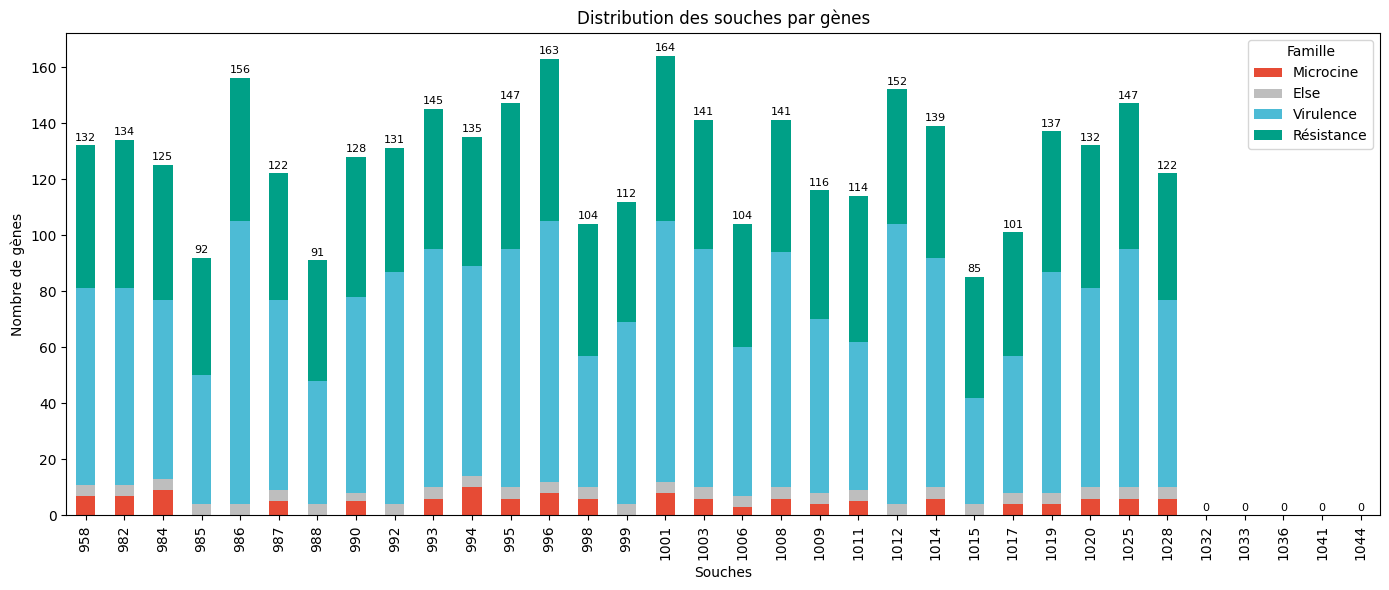

In [24]:
# Tableau souches vs familles
familles = pd.Series(gene_categories)

df_familles = {}
for fam in familles.unique():
    genes_fam = [g for g in familles[familles == fam].index if g in df.columns]
    if genes_fam:
        df_familles[fam] = df[genes_fam].sum(axis=1)
    else:
        df_familles[fam] = 0

df_familles = pd.DataFrame(df_familles)
df_familles["Souche"] = df["Souche"]

df_plot = df_familles.set_index("Souche")

#df_plot = df_plot.loc[df_plot.sum(axis=1) > 0]  # on supprime les lignes vides

colors = {
    "Microcine": "#E64B35",   # rouge brique
    "Virulence": "#4DBBD5",   # bleu turquoise doux
    "Résistance": "#00A087",  # vert sarcelle
    "Else": "#BEBEBE"         # gris clair
}

# Barplot
ax = df_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6),
    color=[colors.get(fam, "gray") for fam in df_plot.columns if fam != "Souche"]
)

# Label
totaux = df_plot.sum(axis=1)
for i, (sou, val) in enumerate(totaux.items()):
    ax.text(i, val + 1, str(val), ha="center", va="bottom", fontsize=8)


plt.ylabel("Nombre de gènes")
plt.xlabel("Souches")
plt.title("Distribution des souches par gènes")
plt.xticks(rotation=90)
plt.legend(title="Famille")
plt.tight_layout()
plt.show()

### Structure des souches dans l'espace des features

In [25]:
# Mapping des libellés
label_map = {
    "Microcine": "Microcine",
    "Résistance":  "Résistance",
    "Virulence":   "Virulence",
    "Else":        "Autres"
}

# Les 3 variables catégories
target_categories = ["Microcine", "Résistance", "Virulence", "Autres"]
categories = {cat: [] for cat in target_categories}
uncategorized = []  # devrait rester vide si tous les retours sont mappés

# Répartition des gènes dans les catégories
for gene, cat in gene_categories.items():
    cat_fr = label_map.get(cat, None)
    if cat_fr in categories:
        categories[cat_fr].append(gene)
    else:
        # Si une catégorie inattendue apparaît, on met le gène ici pour debug
        uncategorized.append(gene)

# Comptage et affichage
print("Nombre de gènes par catégorie :")
for cat in target_categories:
    print(f"{cat:<12}: {len(categories[cat])} gènes")
if uncategorized:
    print(f"Non classés : {len(uncategorized)} gènes -> {uncategorized}")

# Helper pour inclure 'Souche' si présent
def _with_souche(cols):
    if not cols:
        return pd.DataFrame()
    if "Souche" in df.columns:
        return df[["Souche"] + cols]
    return df[cols]  # fallback si 'Souche' n'existe pas

# DataFrames par famille
df_microcine  = _with_souche(categories["Microcine"])
df_resistance = _with_souche(categories["Résistance"])
df_virulence  = _with_souche(categories["Virulence"])
df_autres     = _with_souche(categories["Autres"])  # si besoin

Nombre de gènes par catégorie :
Microcine   : 19 gènes
Résistance  : 69 gènes
Virulence   : 149 gènes
Autres      : 4 gènes


In [26]:
df_mc = pd.read_excel("../data/Features_souches/matrice_bacteriocines_binaires_corrigee.xlsx")

# Remettre Souche en index proprement
df_mc = df_mc.set_index("Souche")

In [27]:
df_mc.shape

(39, 7)

In [28]:
# DataFrame multi-groupes
df_all = pd.concat([
    df_microcine.set_index("Souche"),
    df_resistance.set_index("Souche"),
    df_virulence.set_index("Souche")
], axis=1)

df_all.columns = pd.MultiIndex.from_tuples([
    ("Microcine", col) if col in df_microcine.columns else
    ("Résistance", col) if col in df_resistance.columns else
    ("Virulence", col)
    for col in df_all.columns
])

In [29]:
print(df_all.columns)

MultiIndex([('Microcine', ...),
            ('Microcine', ...),
            ('Microcine', ...),
            ('Microcine', ...),
            ('Microcine', ...),
            ('Microcine', ...),
            ('Microcine', ...),
            ('Microcine', ...),
            ('Microcine', ...),
            ('Microcine', ...),
            ...
            ('Virulence', ...),
            ('Virulence', ...),
            ('Virulence', ...),
            ('Virulence', ...),
            ('Virulence', ...),
            ('Virulence', ...),
            ('Virulence', ...),
            ('Virulence', ...),
            ('Virulence', ...),
            ('Virulence', ...)],
           length=237)


In [30]:
print(df_all.index.name)       # Doit être 'Souche'
print(df_all.columns.levels)   # Affiche les deux niveaux du MultiIndex
print(df_all["Microcine"].shape)  # Dimensions du bloc microcine

Souche
[['Microcine', 'Résistance', 'Virulence'], ['AAC.3..IV', 'ANT.3....IIa', 'APH.3....Ib', 'APH.3...Ia', 'APH.4..Ia', 'APH.6..Id', 'CTX.M.1', 'CTX.M.55', 'ENA.AAA23080.AAA23080.1 Plasmid ColE6-CT14 hypothetical protein', 'ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein', 'ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein', 'ENA.AAA23188.AAA23188.1 Plasmid ColIb hypothetical protein', 'ENA.AAA23189.AAA23189.1 Plasmid ColIb hypothetical protein', 'ENA.AAA23594.AAA23594.1 Plasmid ColBM-Cl139 hypothetical protein', 'ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein', 'ENA.AAC16351.AAC16351.1 Escherichia coli microcin V bacteriocin', 'ENA.AAD28494.AAD28494.1 Escherichia coli microcin J25 precursor', 'ENA.AAD28495.AAD28495.1 Escherichia coli McjB', 'ENA.AAD28497.AAD28497.1 Escherichia coli McjD', 'ENA.CAA30724.CAA30724.1 Escherichia coli hypothetical protein', 'ENA.CAA33859.CAA33859.1 Plasmid ColE5-099 partial colicin E5 (1 is 2nd ba

In [31]:
df_all.head()

Microcine  \
       ENA.AAA23080.AAA23080.1 Plasmid ColE6-CT14 hypothetical protein   
Souche                                                                   
958                                                     1                
982                                                     1                
984                                                     0                
985                                                     0                
986                                                     0                

                                                                            \
       ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein   
Souche                                                                       
958                                                     0                    
982                                                     0                    
984                                                     0                    
985                                                     0                    
986                                                     0                    

                                                                          \
       ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein   
Souche                                                                     
958                                                     0                  
982                                                     0                  
984                                                     0                  
985                                                     0                  
986                                                     0                  

                                                                   \
       ENA.AAA23188.AAA23188.1 Plasmid ColIb hypothetical protein   
Souche                                                              
958                                                     0           
982                                                     0           
984                                                     0           
985                                                     0           
986                                                     0           

                                                                   \
       ENA.AAA23189.AAA23189.1 Plasmid ColIb hypothetical protein   
Souche                                                              
958                                                     0           
982                                                     0           
984                                                     0           
985                                                     0           
986                                                     0           

                                                                         \
       ENA.AAA23594.AAA23594.1 Plasmid ColBM-Cl139 hypothetical protein   
Souche                                                                    
958                                                     0                 
982                                                     0                 
984                                                     1                 
985                                                     0                 
986                                                     0                 

                                                                             \
       ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein   
Souche                                                                        
958                                                     0                     
982                                                     0                     
984                                                     0                     
985                                                  

In [32]:
# MFA
mfa = prince.MFA(
    n_components=5,
    n_iter=5,
    copy=True,
    check_input=True,
    engine="sklearn"
)

mfa = mfa.fit(df_all)

16 [ 0.73837678 -0.93539096]
18 [-0.79255181  0.01454986]
26 [-0.32509768 -0.66019091]
28 [-0.61150061  0.88284741]
19 [-0.32195906 -0.12830257]
25 [-0.17236394  0.28623068]
0 [-0.50502909 -0.35447041]
1 [-0.72885307  0.30010314]
4 [-0.33233675 -0.28997371]
6 [ 0.28644425 -0.48679689]
14 [-0.69724147 -0.2606502 ]
3 [0.37277635 0.9804945 ]
8 [0.57513758 0.12717327]
30 [0.21500247 0.56769779]
31 [0.53619419 0.76507529]
32 [0.46903083 0.56605535]
33 [0.82831088 0.45943054]
21 [-0.01269035 -0.28970393]
23 [-0.79042327 -0.80072052]
29 [-0.37174847  0.77646114]


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


0 [-0.05068161 -0.88068747]
1 [0.43695295 0.96678109]
30 [ 0.13352151 -0.98156709]
31 [ 0.89289169 -0.1754059 ]
32 [0.47253142 0.14080292]
33 [-0.99115448  0.19242668]


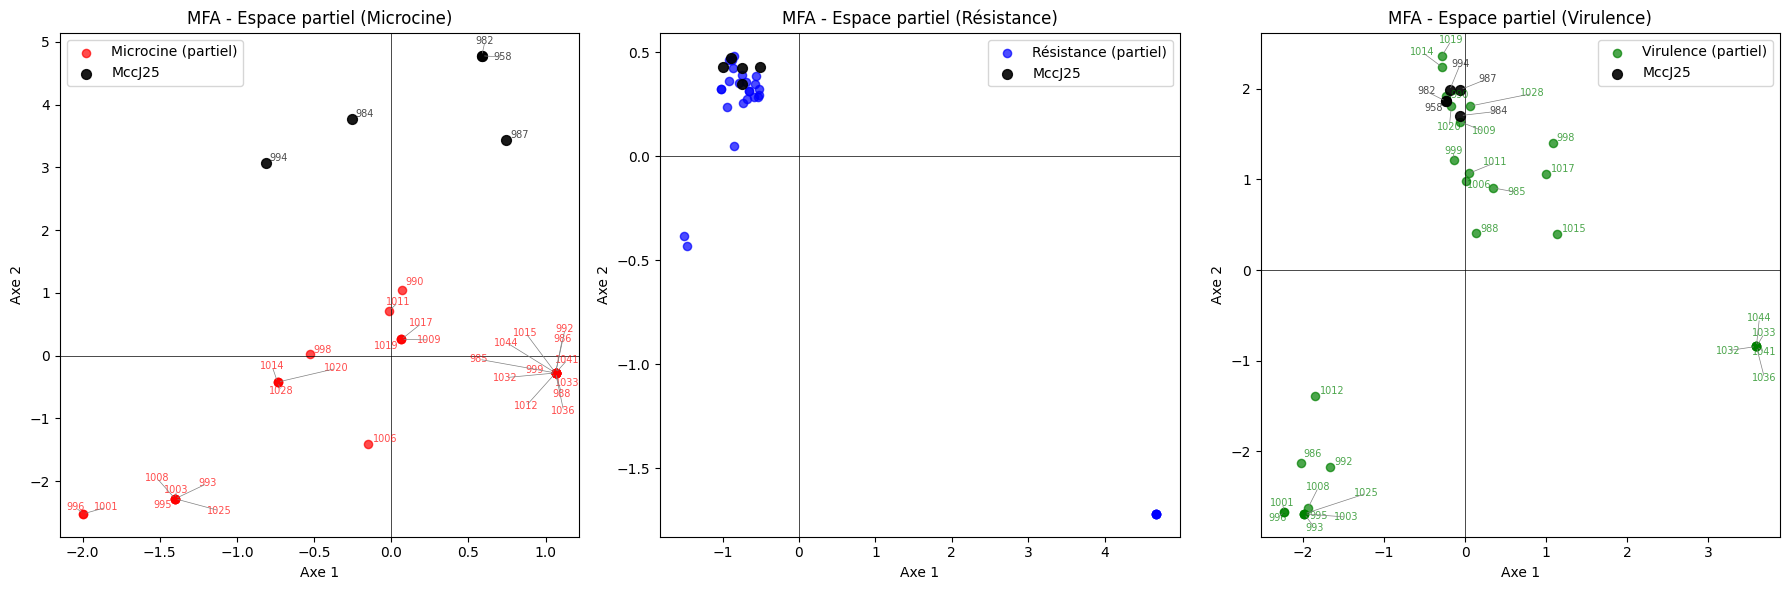

In [33]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Paramètres

colors = {"Microcine": "red", "Résistance": "blue", "Virulence": "green"}
blocs = list(colors.keys())
n_blocs = len(blocs)
mcc_color = "#000000"  # gris foncé pour MccJ25

fig, axes = plt.subplots(1, n_blocs, figsize=(6*n_blocs, 6))

coords_global = mfa.row_coordinates(df_all)
coords_partial = mfa.partial_row_coordinates(df_all)

df_mc = df_mc.loc[coords_global.index]  # réalignement des index

mccJ25_mask = df_mc["MccJ25"] == 1
col_x, col_y = coords_global.columns[0], coords_global.columns[1]

for idx, bloc in enumerate(blocs):
    ax = axes[idx] if n_blocs > 1 else axes

    if bloc not in coords_partial:
        raise KeyError(f"Bloc '{bloc}' absent de coords_partial")

    coords_b = coords_partial[bloc].iloc[:, [0, 1]]

    # Points non MccJ25
    ax.scatter(
        coords_b.loc[~mccJ25_mask, col_x],
        coords_b.loc[~mccJ25_mask, col_y],
        c=colors[bloc],
        s=35,
        alpha=0.7,
        label=f"{bloc} (partiel)"
    )

    # Points MccJ25
    ax.scatter(
        coords_b.loc[mccJ25_mask, col_x],
        coords_b.loc[mccJ25_mask, col_y],
        c=mcc_color,
        s=50,
        alpha=0.9,
        label="MccJ25"
    )

    # Labels pour certains blocs
    if bloc in ["Microcine", "Virulence"]:
        texts = []
        for i in coords_b.index:
            x_val, y_val = coords_b.loc[i, [col_x, col_y]]
            txt = ax.text(
                x_val,
                y_val,
                str(i),
                fontsize=7,
                alpha=0.7,
                color=(mcc_color if mccJ25_mask.loc[i] else colors[bloc])
            )
            texts.append(txt)

        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            force_points=0.3,
            force_text=0.5,
            expand_points=(1.2, 1.4),
            expand_text=(1.2, 1.4)
        )

    # Axes + titre
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"MFA - Espace partiel ({bloc})")
    ax.set_xlabel("Axe 1")
    ax.set_ylabel("Axe 2")
    ax.legend()

plt.tight_layout()
plt.show()

In [34]:
import pandas as pd

# On récupère les résultats MFA
col_contrib = mfa.column_contributions_
col_corr = mfa.column_correlations

# Liste des axes à interpréter
axes = [0, 1]

for ax in axes:
    contrib = col_contrib.iloc[:, ax]
    corr = col_corr.iloc[:, ax]

    # Tableau trié par contribution décroissante
    T = pd.DataFrame({
        "Variable": contrib.index,
        "Contribution (%)": contrib.values,
        "Corrélation": corr.values
    }).sort_values("Contribution (%)", ascending=False).head(10).reset_index(drop=True)

    print(f"\nAxe {ax+1} : Top 10 variables contributives")
    display(T)

    # Conversion en texte si MultiIndex (tuple)
    def to_str(v):
        return f"{v[0]}: {v[1]}" if isinstance(v, tuple) else str(v)

    positives = [to_str(v) for v in T.loc[T["Corrélation"] > 0, "Variable"].tolist()]
    negatives = [to_str(v) for v in T.loc[T["Corrélation"] < 0, "Variable"].tolist()]

    # Texte d’analyse automatique
    res = (
        f"L’axe {ax+1} est principalement structuré par :\n"
        f"- Variables **positivement corrélées** : {', '.join(positives) if positives else 'aucune'}\n"
        f"- Variables **négativement corrélées** : {', '.join(negatives) if negatives else 'aucune'}\n"
    )

    print(res)


Axe 1 : Top 10 variables contributives


,Variable,Contribution (%),Corrélation
0,"(Microcine, ENA.CAA40744.CAA40744.1 Escherichi...",0.027204,-0.587144
1,"(Microcine, ENA.AAC16350.AAC16350.1 Escherichi...",0.025960,-0.573571
2,"(Microcine, ENA.AAA23182.AAA23182.2 Plasmid Co...",0.025451,-0.567913
3,"(Microcine, ENA.AAA23183.AAA23183.1 Plasmid Co...",0.025451,-0.567913
4,"(Microcine, ENA.CAJ44958.CAJ44958.1 Escherichi...",0.024585,-0.558175
5,"(Microcine, ENA.AAA23594.AAA23594.1 Plasmid Co...",0.023036,-0.540306
6,"(Résistance, Escherichia_coli_mdfA)",0.009525,-0.906653
7,"(Résistance, baeR)",0.009525,-0.906653
8,"(Résistance, bacA)",0.009525,-0.906653
9,"(Résistance, Escherichia_coli_acrA)",0.009525,-0.906653


L’axe 1 est principalement structuré par :
- Variables **positivement corrélées** : aucune
- Variables **négativement corrélées** : Microcine: ENA.CAA40744.CAA40744.1 Escherichia coli cvaB protein, Microcine: ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein, Microcine: ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein, Microcine: ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein, Microcine: ENA.CAJ44958.CAJ44958.1 Escherichia coli MchE protein, Microcine: ENA.AAA23594.AAA23594.1 Plasmid ColBM-Cl139 hypothetical protein, Résistance: Escherichia_coli_mdfA, Résistance: baeR, Résistance: bacA, Résistance: Escherichia_coli_acrA


Axe 2 : Top 10 variables contributives


,Variable,Contribution (%),Corrélation
0,"(Microcine, ENA.AAD28494.AAD28494.1 Escherichi...",0.050799,0.698825
1,"(Microcine, ENA.AAD28495.AAD28495.1 Escherichi...",0.050799,0.698825
2,"(Microcine, ENA.AAD28497.AAD28497.1 Escherichi...",0.050799,0.698825
3,"(Microcine, ENA.CAJ40934.CAJ40934.1 Escherichi...",0.050799,0.698825
4,"(Microcine, ENA.CAJ44958.CAJ44958.1 Escherichi...",0.047101,-0.672908
5,"(Microcine, ENA.AAA23594.AAA23594.1 Plasmid Co...",0.027395,-0.513189
6,"(Microcine, ENA.AAA23080.AAA23080.1 Plasmid Co...",0.024709,0.487383
7,"(Microcine, ENA.CAA33859.CAA33859.1 Plasmid Co...",0.024709,0.487383
8,"(Microcine, ENA.CAA33860.CAA33860.1 Plasmid Co...",0.024709,0.487383
9,"(Microcine, ENA.CAA40743.CAA40743.1 Escherichi...",0.024683,0.487125


L’axe 2 est principalement structuré par :
- Variables **positivement corrélées** : Microcine: ENA.AAD28494.AAD28494.1 Escherichia coli microcin J25 precursor, Microcine: ENA.AAD28495.AAD28495.1 Escherichia coli McjB, Microcine: ENA.AAD28497.AAD28497.1 Escherichia coli McjD, Microcine: ENA.CAJ40934.CAJ40934.1 Escherichia coli microcin J25 processing protein, Microcine: ENA.AAA23080.AAA23080.1 Plasmid ColE6-CT14 hypothetical protein, Microcine: ENA.CAA33859.CAA33859.1 Plasmid ColE5-099 partial colicin E5 (1 is 2nd base in codon), Microcine: ENA.CAA33860.CAA33860.1 Plasmid ColE5-099 immunity protein (AA 1-83), Microcine: ENA.CAA40743.CAA40743.1 Escherichia coli cvaA protein
- Variables **négativement corrélées** : Microcine: ENA.CAJ44958.CAJ44958.1 Escherichia coli MchE protein, Microcine: ENA.AAA23594.AAA23594.1 Plasmid ColBM-Cl139 hypothetical protein



In [35]:
import numpy as np
# Variance (inertie) par axe sur l'espace complet (d_max)
# Cchaque colonne = un axe
V = coords_global.values
var_axes = np.var(V, axis=0)
var_axes = var_axes / var_axes.sum()           # proportions par axe (somme=1 sur d_max)
var_cum = np.cumsum(var_axes)

print("Variance par axe (premiers axes) :")
for i, v in enumerate(var_axes[:2], start=1):
    print(f"Axe {i:2d}: {v*100:.2f}%")

print("\nVariance cumulée :")
for i, v in enumerate(var_cum[:2], start=1):
    print(f"Jusqu'à l'axe {i:2d}: {v*100:.2f}%")

Variance par axe (premiers axes) :
Axe  1: 36.69%
Axe  2: 27.83%

Variance cumulée :
Jusqu'à l'axe  1: 36.69%
Jusqu'à l'axe  2: 64.53%


30 [ 0.85589408 -0.49107752]
31 [0.20469008 0.04349751]
32 [-0.35249073 -0.71490887]
33 [0.17565468 0.86841313]
30 [-0.29120217  0.69345322]
31 [ 0.39457456 -0.26832094]
32 [-0.59261834 -0.77706385]
33 [-0.25084222 -0.2542259 ]
30 [0.59490099 0.36353726]
31 [ 0.65731663 -0.26386223]
32 [-0.95421678 -0.53789549]
33 [0.88826448 0.20060122]


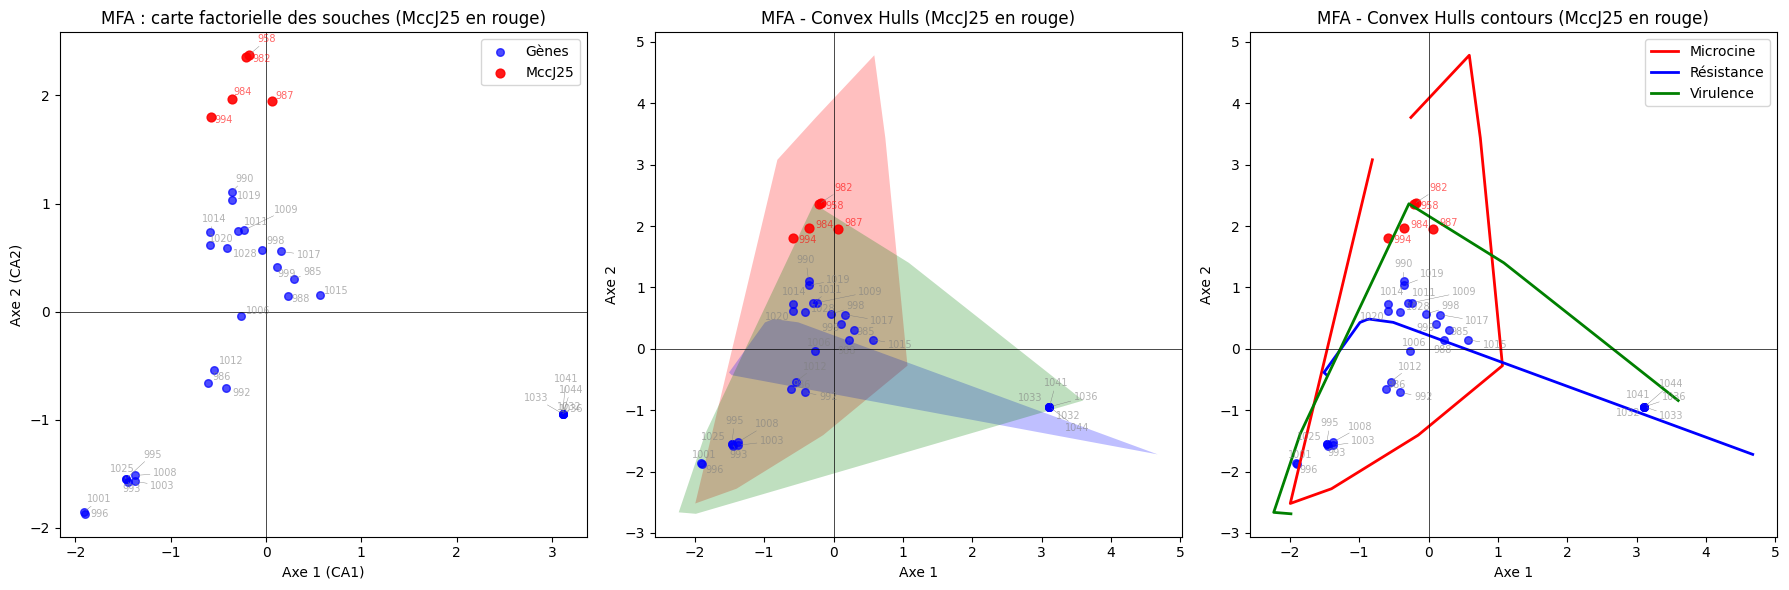

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

coords_global = mfa.row_coordinates(df_all)
coords_partial = mfa.partial_row_coordinates(df_all)
colors = {"Microcine": "red", "Résistance": "blue", "Virulence": "green"}

df_mc = df_mc.loc[coords_global.index]  # réalignement
mccJ25_mask = df_mc["MccJ25"] == 1
col_x, col_y = coords_global.columns[0], coords_global.columns[1]

# Carte factorielle globale
ax = axes[0]
ax.scatter(coords_global.loc[~mccJ25_mask, col_x],
           coords_global.loc[~mccJ25_mask, col_y],
           c="blue", s=30, alpha=0.7, label="Gènes")
ax.scatter(coords_global.loc[mccJ25_mask, col_x],
           coords_global.loc[mccJ25_mask, col_y],
           c="red", s=40, alpha=0.9, label="MccJ25")

# Labels ajustés
texts = []
for i, souche in enumerate(coords_global.index):
    x, y = coords_global.iloc[i, 0], coords_global.iloc[i, 1]
    txt = ax.text(x, y, str(souche),
                  fontsize=7, alpha=0.6,
                  color=("red" if mccJ25_mask.iloc[i] else "gray"))
    texts.append(txt)
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.3))

ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title("MFA : carte factorielle des souches (MccJ25 en rouge)")
ax.set_xlabel("Axe 1 (CA1)")
ax.set_ylabel("Axe 2 (CA2)")
ax.legend()

# MFA – Convex Hulls (zones colorées)
ax = axes[1]
for bloc, color in colors.items():
    coords_b = coords_partial[bloc].iloc[:, [0, 1]]
    try:
        hull = ConvexHull(coords_b.values)
        polygon = plt.Polygon(coords_b.values[hull.vertices],
                              facecolor=color, alpha=0.25, label=bloc)
        ax.add_patch(polygon)
    except:
        pass

ax.scatter(coords_global.loc[~mccJ25_mask, col_x],
           coords_global.loc[~mccJ25_mask, col_y],
           c="blue", s=30, alpha=0.7)
ax.scatter(coords_global.loc[mccJ25_mask, col_x],
           coords_global.loc[mccJ25_mask, col_y],
           c="red", s=40, alpha=0.9)

texts = []
for i, souche in enumerate(coords_global.index):
    x, y = coords_global.iloc[i, 0], coords_global.iloc[i, 1]
    txt = ax.text(x, y, str(souche),
                  fontsize=7, alpha=0.6,
                  color=("red" if mccJ25_mask.iloc[i] else "gray"))
    texts.append(txt)
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.3))

ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title("MFA - Convex Hulls (MccJ25 en rouge)")
ax.set_xlabel("Axe 1")
ax.set_ylabel("Axe 2")

# MFA – Convex Hulls (contours)
ax = axes[2]
for bloc, color in colors.items():
    coords_b = coords_partial[bloc].iloc[:, [0, 1]]
    try:
        hull = ConvexHull(coords_b.values)
        ax.plot(coords_b.values[hull.vertices, 0],
                coords_b.values[hull.vertices, 1],
                color=color, linewidth=2, label=bloc)
    except:
        pass

ax.scatter(coords_global.loc[~mccJ25_mask, col_x],
           coords_global.loc[~mccJ25_mask, col_y],
           c="blue", s=30, alpha=0.7)
ax.scatter(coords_global.loc[mccJ25_mask, col_x],
           coords_global.loc[mccJ25_mask, col_y],
           c="red", s=40, alpha=0.9)

texts = []
for i, souche in enumerate(coords_global.index):
    x, y = coords_global.iloc[i, 0], coords_global.iloc[i, 1]
    txt = ax.text(x, y, str(souche),
                  fontsize=7, alpha=0.6,
                  color=("red" if mccJ25_mask.iloc[i] else "gray"))
    texts.append(txt)
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.3))

ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title("MFA - Convex Hulls contours (MccJ25 en rouge)")
ax.set_xlabel("Axe 1")
ax.set_ylabel("Axe 2")
ax.legend()

plt.tight_layout()
plt.show()

On doit relier individus ↔ variables

Pour interpréter la position d’un individu par rapport aux variables :

On regarde le signe et la valeur de sa coordonnée sur l’axe :

si elle est grande et positive → l’individu est “du côté” des variables corrélées positivement avec l’axe ;

si c'est négatif → il est du côté opposé, lié aux variables corrélées négativement avec l’axe.

On regarde quelles variables contribuent le plus à cet axe :
ce sont elles qui définissent la signification de la direction.

16 [-0.50090304  0.26819922]
18 [0.95243175 0.15469968]
26 [-0.58680207 -0.45593816]
28 [ 0.3531316  -0.18554234]
19 [-0.03753737  0.32226684]
25 [-0.34035874 -0.26626104]
0 [-0.95094239  0.5499247 ]
1 [0.82822303 0.54234243]
4 [0.10679588 0.53490917]
6 [-0.68497491 -0.45280493]
14 [ 0.10258516 -0.46416651]
3 [0.64855441 0.06502986]
8 [0.68205618 0.34218288]
30 [ 0.78341055 -0.41563704]
31 [0.39164839 0.68340081]
32 [-0.55197947  0.66208513]
33 [-0.57168343 -0.46403781]
21 [-0.92617828 -0.33781529]
23 [-0.67264873 -0.78986505]
29 [0.40107006 0.03721856]
0 [0.29026287 0.56562922]
1 [-0.05491511  0.61964996]
30 [0.1871096 0.8461768]
31 [-0.59872596  0.026838  ]
32 [0.26615512 0.48768477]
33 [-0.33799728  0.58825087]


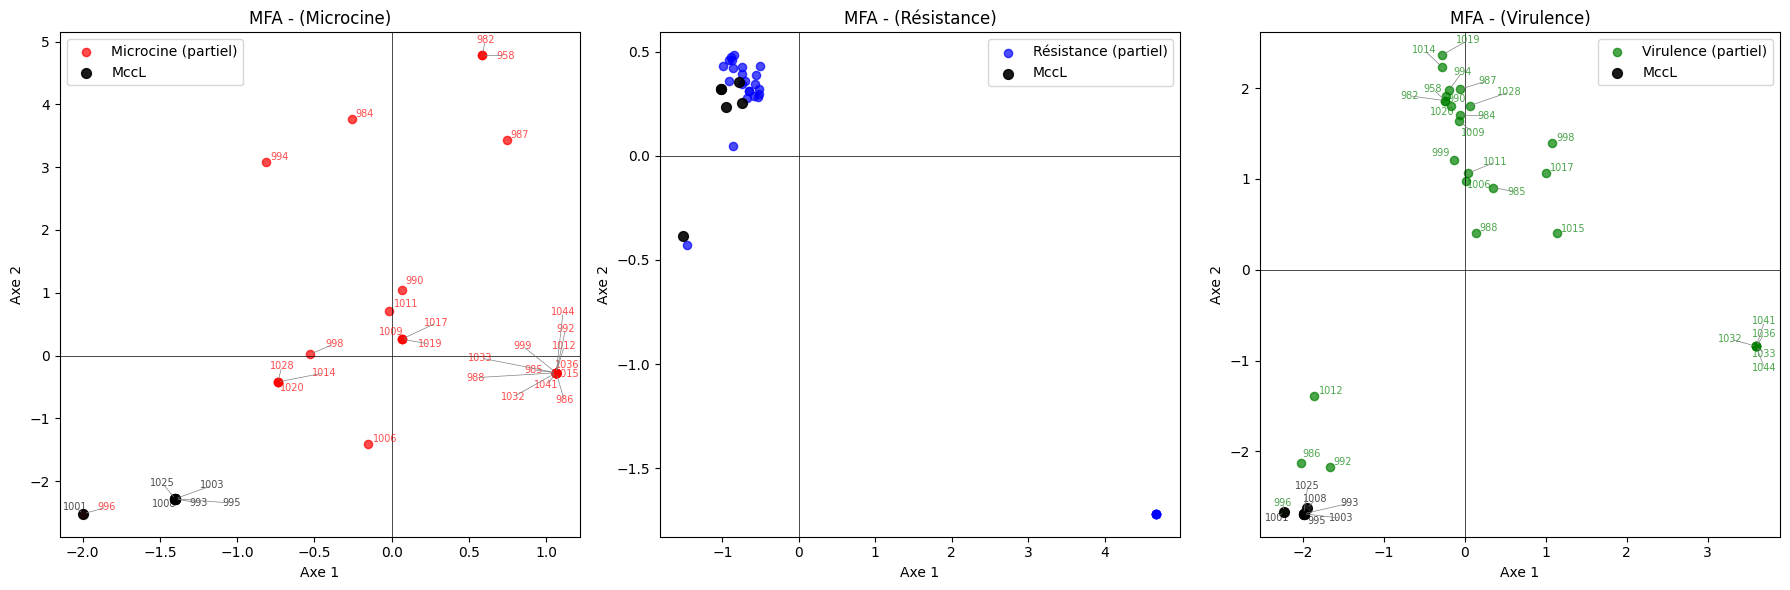

In [37]:
# Paramètres

colors = {"Microcine": "red", "Résistance": "blue", "Virulence": "green"}
blocs = list(colors.keys())
n_blocs = len(blocs)
mcc_color = "#000000"  # gris foncé pour MccJ25

fig, axes = plt.subplots(1, n_blocs, figsize=(6*n_blocs, 6))

coords_global = mfa.row_coordinates(df_all)
coords_partial = mfa.partial_row_coordinates(df_all)

df_mc = df_mc.loc[coords_global.index]  # réalignement des index

mccJ25_mask = df_mc["MccL"] == 1
col_x, col_y = coords_global.columns[0], coords_global.columns[1]

for idx, bloc in enumerate(blocs):
    ax = axes[idx] if n_blocs > 1 else axes

    if bloc not in coords_partial:
        raise KeyError(f"Bloc '{bloc}' absent de coords_partial")

    coords_b = coords_partial[bloc].iloc[:, [0, 1]]

    # Points non MccL
    ax.scatter(
        coords_b.loc[~mccJ25_mask, col_x],
        coords_b.loc[~mccJ25_mask, col_y],
        c=colors[bloc],
        s=35,
        alpha=0.7,
        label=f"{bloc} (partiel)"
    )

    # Points MccJ25
    ax.scatter(
        coords_b.loc[mccJ25_mask, col_x],
        coords_b.loc[mccJ25_mask, col_y],
        c=mcc_color,
        s=50,
        alpha=0.9,
        label="MccL"
    )

    # Labels pour certains blocs
    if bloc in ["Microcine", "Virulence"]:
        texts = []
        for i in coords_b.index:
            x_val, y_val = coords_b.loc[i, [col_x, col_y]]
            txt = ax.text(
                x_val,
                y_val,
                str(i),
                fontsize=7,
                alpha=0.7,
                color=(mcc_color if mccJ25_mask.loc[i] else colors[bloc])
            )
            texts.append(txt)

        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            force_points=0.3,
            force_text=0.5,
            expand_points=(1.2, 1.4),
            expand_text=(1.2, 1.4)
        )

    # Axes + titre
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"MFA - ({bloc})")
    ax.set_xlabel("Axe 1")
    ax.set_ylabel("Axe 2")
    ax.legend()

plt.tight_layout()
plt.show()

16 [-0.66221218 -0.64098829]
18 [-0.97146425  0.23002327]
26 [0.84197721 0.80501992]
28 [ 0.30371333 -0.5467097 ]
19 [ 0.55558357 -0.18516018]
25 [0.36165695 0.01289935]
0 [0.30493797 0.47522766]
1 [-0.61875775  0.32826145]
4 [ 0.26760053 -0.08244624]
6 [ 0.5907353  -0.54193405]
14 [ 0.42928227 -0.44601849]
3 [ 0.58510936 -0.07043357]
8 [-0.7003066  -0.63947785]
30 [ 0.07755059 -0.55331004]
31 [-0.70833644 -0.61756104]
32 [ 0.98121155 -0.50087094]
33 [ 0.13836545 -0.21058851]
21 [-0.11244265 -0.90110925]
23 [0.86247366 0.98668847]
29 [0.28372787 0.13432085]
0 [-0.96550675 -0.86701701]
1 [ 0.07870917 -0.66710393]
30 [ 0.66730732 -0.56457655]
31 [-0.91322827  0.96067672]
32 [0.86423659 0.98029616]
33 [-0.06505599  0.52926329]


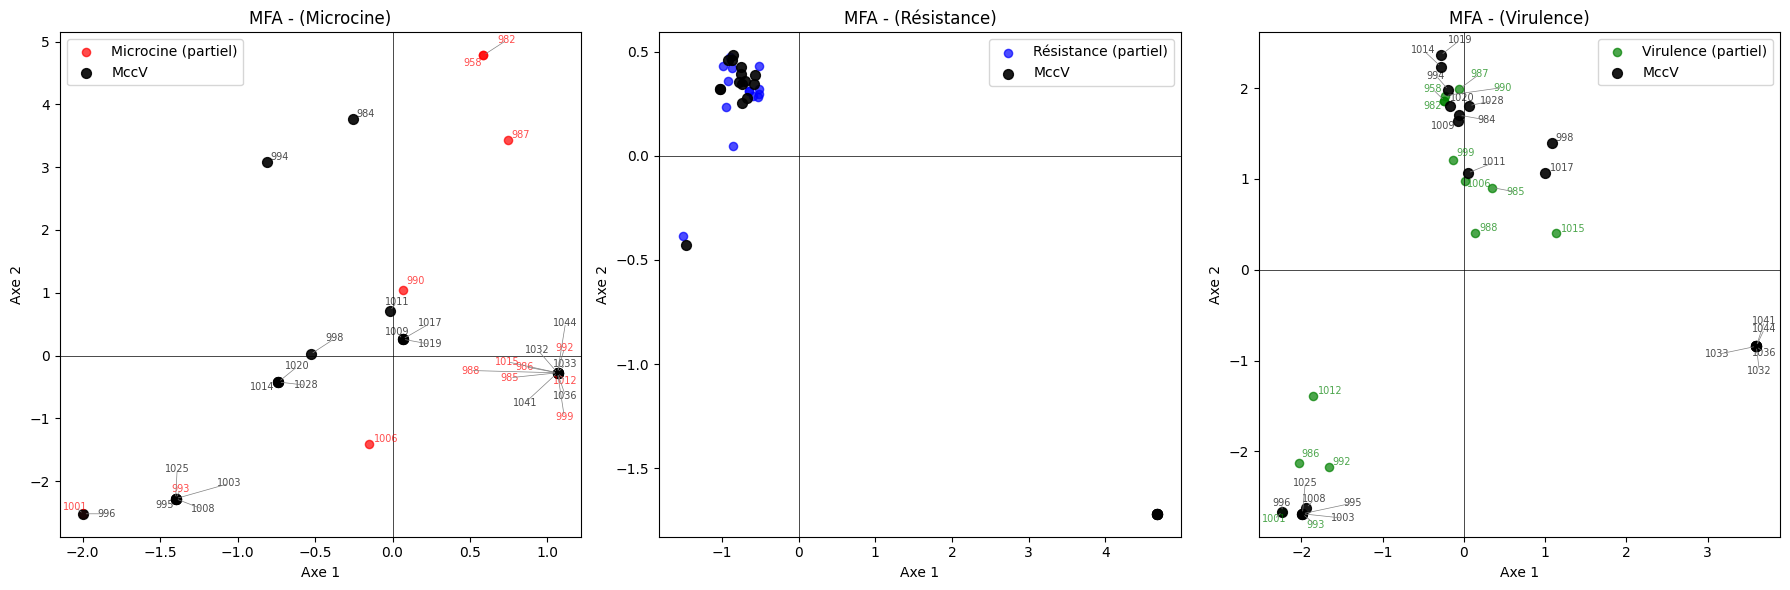

In [38]:
# Paramètres

colors = {"Microcine": "red", "Résistance": "blue", "Virulence": "green"}
blocs = list(colors.keys())
n_blocs = len(blocs)
mcc_color = "#000000"  # gris foncé pour MccJ25

fig, axes = plt.subplots(1, n_blocs, figsize=(6*n_blocs, 6))

coords_global = mfa.row_coordinates(df_all)
coords_partial = mfa.partial_row_coordinates(df_all)

df_mc = df_mc.loc[coords_global.index]  # réalignement des index

mccJ25_mask = df_mc["MccV"] == 1
col_x, col_y = coords_global.columns[0], coords_global.columns[1]

for idx, bloc in enumerate(blocs):
    ax = axes[idx] if n_blocs > 1 else axes

    if bloc not in coords_partial:
        raise KeyError(f"Bloc '{bloc}' absent de coords_partial")

    coords_b = coords_partial[bloc].iloc[:, [0, 1]]

    # Points non ColV
    ax.scatter(
        coords_b.loc[~mccJ25_mask, col_x],
        coords_b.loc[~mccJ25_mask, col_y],
        c=colors[bloc],
        s=35,
        alpha=0.7,
        label=f"{bloc} (partiel)"
    )

    # Points MccJ25
    ax.scatter(
        coords_b.loc[mccJ25_mask, col_x],
        coords_b.loc[mccJ25_mask, col_y],
        c=mcc_color,
        s=50,
        alpha=0.9,
        label="MccV"
    )

    # Labels pour certains blocs
    if bloc in ["Microcine", "Virulence"]:
        texts = []
        for i in coords_b.index:
            x_val, y_val = coords_b.loc[i, [col_x, col_y]]
            txt = ax.text(
                x_val,
                y_val,
                str(i),
                fontsize=7,
                alpha=0.7,
                color=(mcc_color if mccJ25_mask.loc[i] else colors[bloc])
            )
            texts.append(txt)

        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            force_points=0.3,
            force_text=0.5,
            expand_points=(1.2, 1.4),
            expand_text=(1.2, 1.4)
        )

    # Axes + titre
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"MFA - ({bloc})")
    ax.set_xlabel("Axe 1")
    ax.set_ylabel("Axe 2")
    ax.legend()

plt.tight_layout()
plt.show()

### Structuration des gènes

In [39]:
genes_categorized = [gene for gene, cat in gene_categories.items() if cat != "Else"]
df_filtered = df_genes[genes_categorized]
df_filtered.shape

(34, 237)

In [40]:
# Calcul de la matrice Jaccard (similarité)
X = df_filtered.T.values
D = pairwise_distances(X, metric='jaccard')
S = 1 - D
df_jaccard = pd.DataFrame(S, index=genes_categorized, columns=genes_categorized)

/home/stevensia/Documents/sam2/sam2/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [41]:
# Fonction pour un graphe de similarité entre gènes

def construire_graphe(seuil):
    G = nx.Graph()

    for gene in genes_categorized:
        G.add_node(gene, catégorie=gene_categories[gene])

    # Ajout des arêtes si la mesure depasse le seuil
    for i, gene_i in enumerate(genes_categorized):
        for j, gene_j in enumerate(genes_categorized):
            if j <= i:
                continue
            sim = df_jaccard.iloc[i, j]
            if sim >= seuil:
                G.add_edge(gene_i, gene_j, weight=sim)

    return G

In [42]:
# On réutilise toujours le même layout (positions fixes des gènes)
def layout_fixe(G):
    return nx.spring_layout(G, seed=42, k=0.2)

def afficher_graphe_comparatif(seuils, G_fabrique, layout=None):
    n = len(seuils)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), constrained_layout=True)

    G0 = G_fabrique(seuils[0])
    if layout is None:
        layout = layout_fixe(G0)

    color_map = {
        "Microcine": "red",
        "Résistance": "blue",
        "Virulence": "green"
    }

    for i, seuil in enumerate(seuils):
        G = G_fabrique(seuil)
        ax = axes[i]

        # Couleurs des nœuds
        node_colors = [color_map[G.nodes[n]["catégorie"]] for n in G.nodes]

        # Tracé du graphe
        nx.draw_networkx_nodes(G, layout, ax=ax, node_color=node_colors, node_size=60)
        nx.draw_networkx_edges(G, layout, ax=ax, alpha=0.4, width=0.5)

        # Légende
        for fam, col in color_map.items():
            ax.scatter([], [], c=col, s=60, label=fam)

        ax.legend()

        ax.set_title(f"Seuil Jaccard ≥ {seuil}", fontsize=14)
        ax.axis("off")
        rect = patches.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            linewidth=1.5,
            edgecolor='lightgray',
            facecolor='none'
        )
        ax.add_patch(rect)

    plt.show()

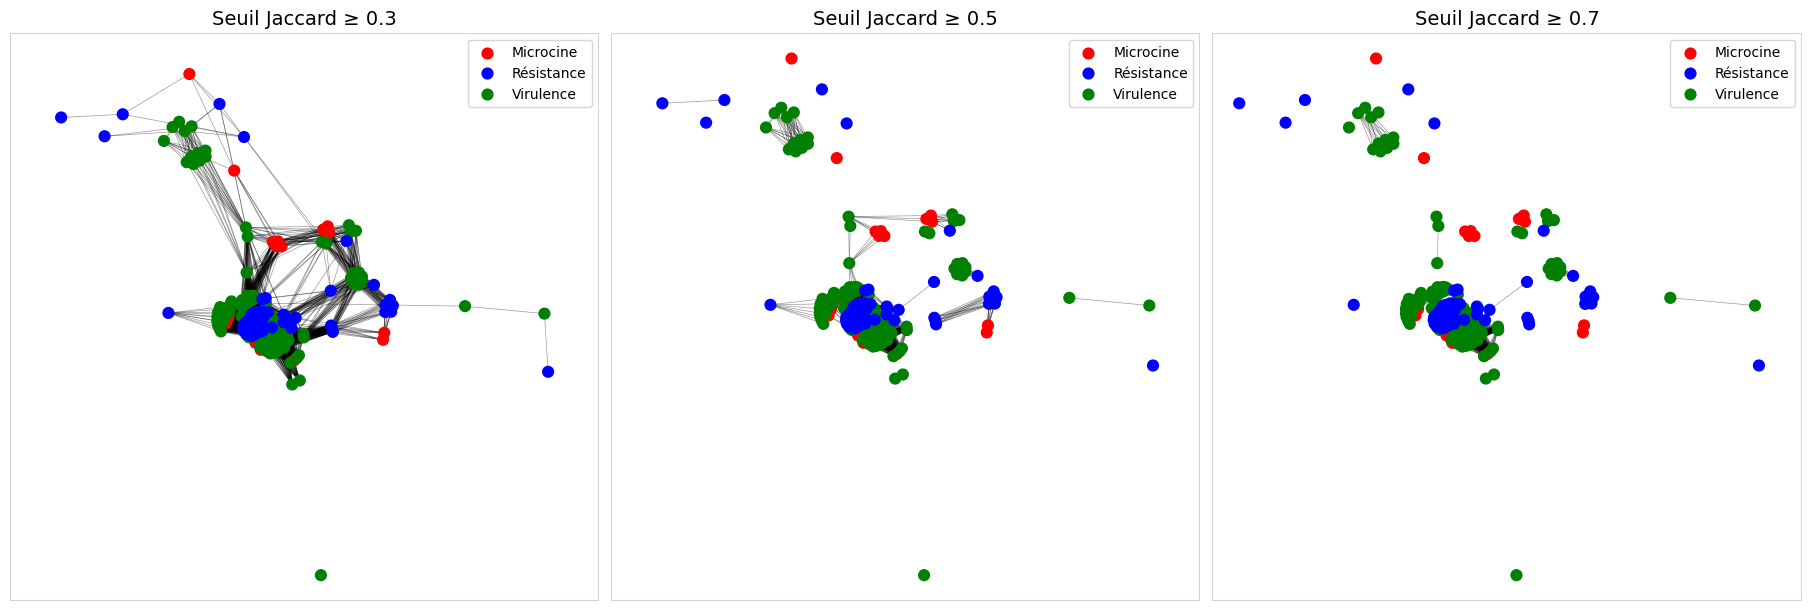

In [43]:
afficher_graphe_comparatif([0.3, 0.5, 0.7], construire_graphe)

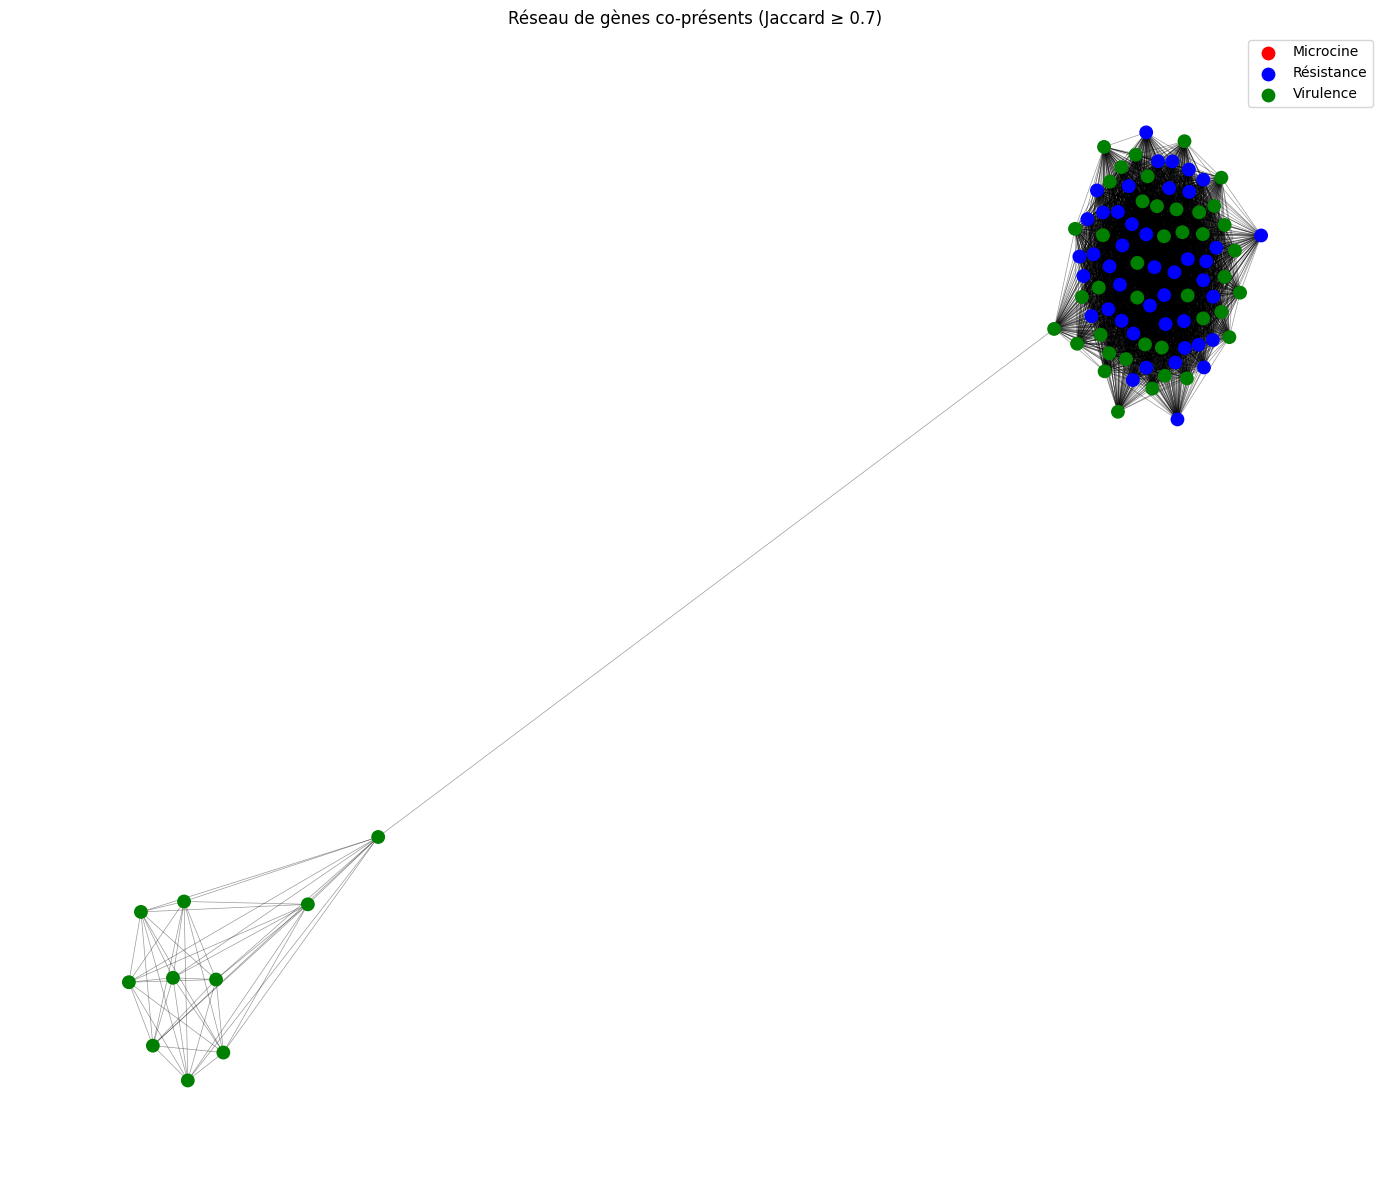

Nombre de nœuds : 95
Nombre d’arêtes : 3574


In [44]:
# Réseau de gènes dont la similarité dépasse 0.7

threshold = 0.7
G = nx.Graph()  # Construction du graphe avec NetworkX


# Ajout des nœuds avec leur catégorie
for gene in genes_categorized:
    G.add_node(gene, catégorie=gene_categories[gene])

# Ajout des arêtes pondérées (si similarité ≥ seuil)
for i, gene_i in enumerate(genes_categorized):
    for j, gene_j in enumerate(genes_categorized):
        if j <= i:
            continue
        sim = df_jaccard.iloc[i, j]
        if sim >= threshold:
            G.add_edge(gene_i, gene_j, weight=sim)

if not nx.is_connected(G):
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

# Affichage du graphe coloré

color_map = {
    "Microcine": "red",
    "Résistance": "blue",
    "Virulence": "green"
}
node_colors = [color_map[G.nodes[n]['catégorie']] for n in G.nodes]

plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, seed=42, k=0.2)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=80)
nx.draw_networkx_edges(G, pos, alpha=0.4, width=0.5)
#nx.draw_networkx_labels(G, pos, font_size=7)

for fam, col in color_map.items():
    plt.scatter([], [], c=col, s=80, label=fam)
plt.legend()

plt.title("Réseau de gènes co-présents (Jaccard ≥ 0.7)")
plt.axis("off")
plt.tight_layout()
plt.show()


print(f"Nombre de nœuds : {G.number_of_nodes()}")
print(f"Nombre d’arêtes : {G.number_of_edges()}")

In [45]:
def visualiser_distribution_cluster(G, df_genes_binaires, titre=""):
    # On extraire le plus gros cluster (composante connexe)
    largest_cc = max(nx.connected_components(G), key=len)
    cluster_genes = sorted(list(largest_cc))

    # Extraction des profils binaires pour ces gènes
    df_cluster = df_genes_binaires[cluster_genes]

    # On trie les souches par nombre de gènes présents dans le cluster
    df_cluster["total_pres"] = df_cluster.sum(axis=1)
    df_cluster = df_cluster.sort_values("total_pres", ascending=False).drop(columns="total_pres")


    plt.figure(figsize=(1 + len(cluster_genes)*0.3, 10))
    sns.heatmap(df_cluster, cmap=["#eeeeee", "#007acc"], cbar=False, linewidths=0.5, linecolor='lightgray')
    plt.title(f"Présence/absence des gènes du cluster ({titre})", fontsize=14)
    plt.xlabel("Gènes")
    plt.ylabel("Souches")
    plt.xticks(rotation=90)
    plt.show()

    print("\nTaux moyen de gènes présents par souche (sur cluster) :")
    print((df_cluster.sum(axis=1) / len(cluster_genes)).describe().round(2))

/tmp/ipykernel_9914/880082060.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster["total_pres"] = df_cluster.sum(axis=1)


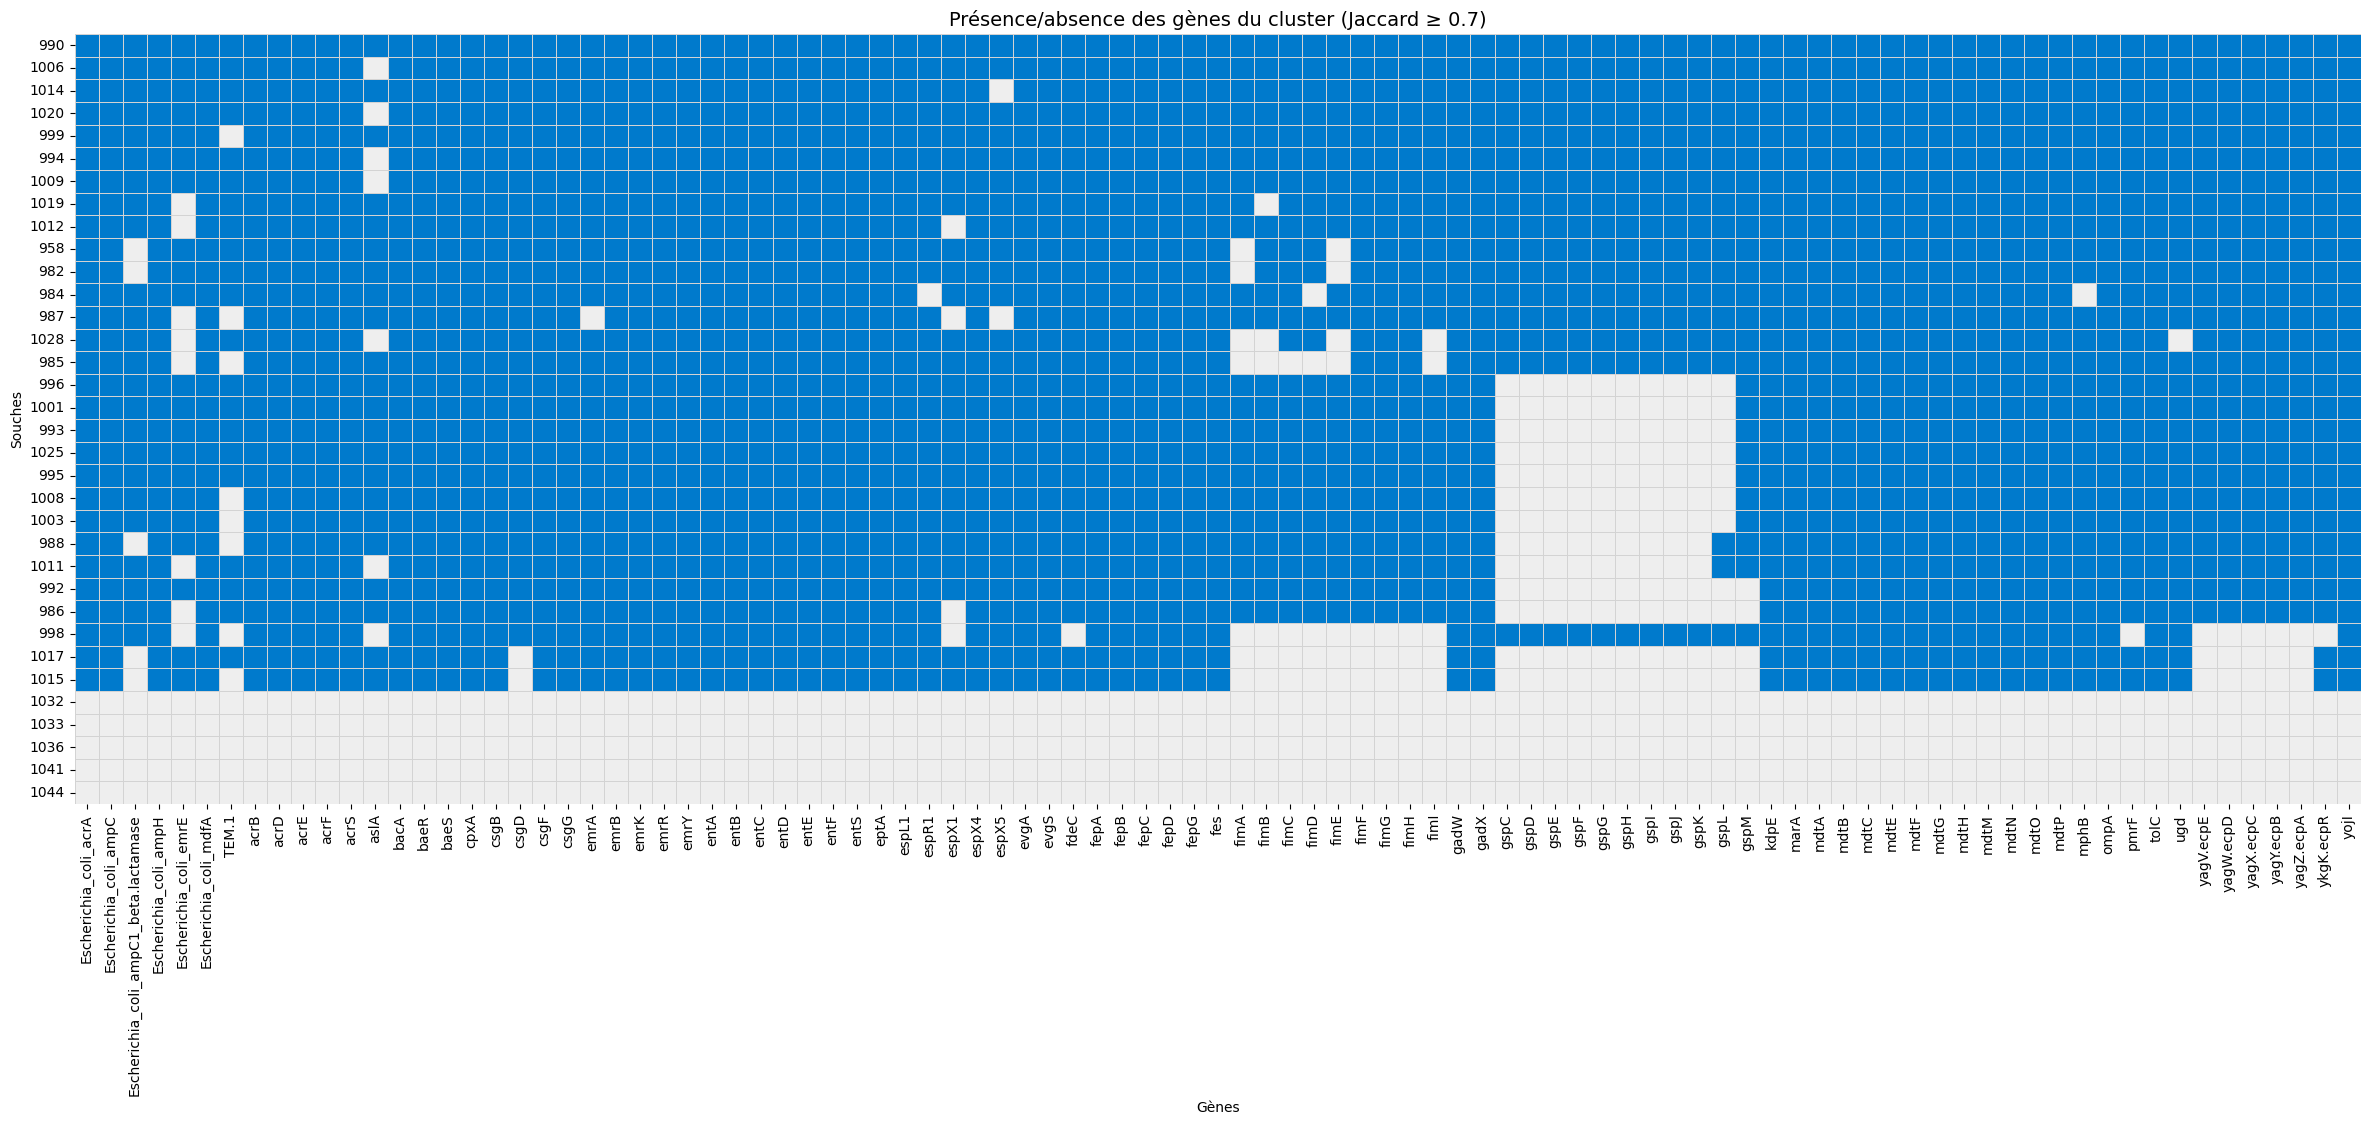


Taux moyen de gènes présents par souche (sur cluster) :
count    34.00
mean      0.78
std       0.34
min       0.00
25%       0.87
50%       0.89
75%       0.98
max       1.00
dtype: float64


In [46]:
# Graphe à seuil 0.7
G_07 = construire_graphe(0.7)

df_genes_binaires = df[["Souche"] + genes_categorized].set_index("Souche")

visualiser_distribution_cluster(G_07, df_genes_binaires, titre="Jaccard ≥ 0.7")

In [47]:
print(df.columns.tolist())  # Pour voir tous les noms de colonnes réels
print(set(["Souche"] + genes_categorized) - set(df.columns))  # Pour voir celles qui manquent

['Souche', 'ENA.AAA23080.AAA23080.1 Plasmid ColE6-CT14 hypothetical protein', 'ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein', 'ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein', 'ENA.AAA23188.AAA23188.1 Plasmid ColIb hypothetical protein', 'ENA.AAA23189.AAA23189.1 Plasmid ColIb hypothetical protein', 'ENA.AAA23594.AAA23594.1 Plasmid ColBM-Cl139 hypothetical protein', 'ENA.AAB61768.AAB61768.1 Escherichia coli ferrichrome-iron receptor', 'ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein', 'ENA.AAC16351.AAC16351.1 Escherichia coli microcin V bacteriocin', 'ENA.AAC73892.AAC73892.1 Escherichia coli str. K-12 substr. MG1655 iron catecholate outer membrane transporter Fiu', 'ENA.AAD28494.AAD28494.1 Escherichia coli microcin J25 precursor', 'ENA.AAD28495.AAD28495.1 Escherichia coli McjB', 'ENA.AAD28497.AAD28497.1 Escherichia coli McjD', 'ENA.CAA30724.CAA30724.1 Escherichia coli hypothetical protein', 'ENA.CAA33859.CAA33859.1 Plasmid C

### Test de Mantel
Pour valider statistiquement si les similarités/co-présences observées entre les gènes sont dues au hasard ou pas

In [48]:
# Test de Mantel

categories = {
    "Microcine": [g for g, c in gene_categories.items() if c == "Microcine"],
    "Résistance": [g for g, c in gene_categories.items() if c == "Résistance"],
    "Virulence": [g for g, c in gene_categories.items() if c == "Virulence"]
}

# Matrice de distances Jaccard
def get_jaccard_matrix(df, cols):
    if len(cols) == 0:
        return None
    X = df[cols].values
    return pairwise_distances(X, metric="jaccard")

# Calcul des matrices de distances
D_microcine  = get_jaccard_matrix(df, categories["Microcine"])
D_resistance = get_jaccard_matrix(df, categories["Résistance"])
D_virulence  = get_jaccard_matrix(df, categories["Virulence"])

# Fonction pour appliquer Mantel entre deux groupes
def mantel_between(D1, D2, name1, name2):
    if D1 is None or D2 is None:
        return {"familles": f"{name1} vs {name2}", "r": np.nan, "p": np.nan}
    r, p, _ = mantel(D1, D2, method="pearson", permutations=999)
    return {"familles": f"{name1} vs {name2}", "r": r, "p": p}

# Comparaisons par paires
results = []
results.append(mantel_between(D_microcine, D_resistance, "Microcine", "Résistance"))
results.append(mantel_between(D_microcine, D_virulence, "Microcine", "Virulence"))
results.append(mantel_between(D_resistance, D_virulence, "Résistance", "Virulence"))

df_results = pd.DataFrame(results)

#print("\n Résultats du test de Mantel (999 permutations)")
#print(df_results.to_string(index=False))
df_results

/home/stevensia/Documents/sam2/sam2/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/home/stevensia/Documents/sam2/sam2/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/home/stevensia/Documents/sam2/sam2/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


,familles,r,p
0,Microcine vs Résistance,0.046888,0.390
1,Microcine vs Virulence,0.211210,0.001
2,Résistance vs Virulence,0.800950,0.001


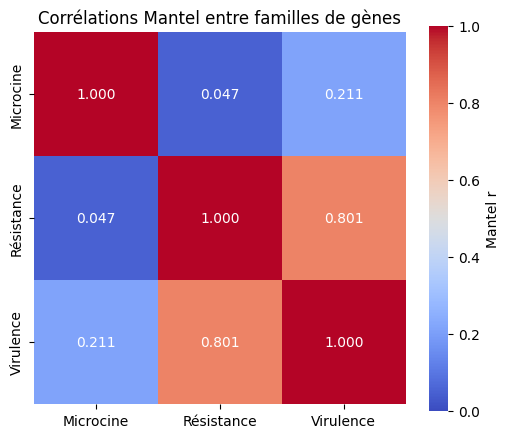

In [49]:
# Heatmap des corrélations Mantel
familles = ["Microcine", "Résistance", "Virulence"]
mat_r = pd.DataFrame(np.eye(len(familles)), index=familles, columns=familles)


for _, row in df_results.iterrows():
    f1, f2 = row["familles"].split(" vs ")
    mat_r.loc[f1, f2] = row["r"]
    mat_r.loc[f2, f1] = row["r"]

plt.figure(figsize=(6,5))
sns.heatmap(mat_r, annot=True, fmt=".3f", cmap="coolwarm", vmin=0, vmax=1, square=True,
            cbar_kws={"label": "Mantel r"})
plt.title("Corrélations Mantel entre familles de gènes")
plt.show()

### Analyse de similarité de structure des souches par famille de gènes avec Procrustes

In [50]:
# Nombre maximum d'axes
d_max = min(df_all.shape[0] - 1, df_all.shape[1])

mfa = prince.MFA(
    n_components=d_max,
    n_iter=5,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42
).fit(df_all)

# Coordonnées globales et partielles (toutes dimensions)
coords_global = mfa.row_coordinates(df_all)                  # (n_souches × d_max)
partials = mfa.partial_row_coordinates(df_all)               # dict par groupe
coords_microcine  = partials["Microcine"]
coords_resistance = partials["Résistance"]
coords_virulence  = partials["Virulence"]

In [51]:
# Variance (inertie) par axe sur l'espace complet (d_max)
# Cchaque colonne = un axe
V = coords_global.values
var_axes = np.var(V, axis=0)
var_axes = var_axes / var_axes.sum()           # proportions par axe (somme=1 sur d_max)
var_cum = np.cumsum(var_axes)

print("Variance par axe (premiers axes) :")
for i, v in enumerate(var_axes[:30], start=1):
    print(f"Axe {i:2d}: {v*100:.2f}%")

print("\nVariance cumulée :")
for i, v in enumerate(var_cum[:30], start=1):
    print(f"Jusqu'à l'axe {i:2d}: {v*100:.2f}%")

Variance par axe (premiers axes) :
Axe  1: 27.30%
Axe  2: 20.71%
Axe  3: 12.73%
Axe  4: 7.52%
Axe  5: 6.15%
Axe  6: 5.53%
Axe  7: 3.45%
Axe  8: 2.81%
Axe  9: 2.63%
Axe 10: 1.95%
Axe 11: 1.74%
Axe 12: 1.42%
Axe 13: 1.04%
Axe 14: 0.93%
Axe 15: 0.81%
Axe 16: 0.72%
Axe 17: 0.63%
Axe 18: 0.49%
Axe 19: 0.38%
Axe 20: 0.31%
Axe 21: 0.24%
Axe 22: 0.17%
Axe 23: 0.13%
Axe 24: 0.11%
Axe 25: 0.06%
Axe 26: 0.03%
Axe 27: 0.02%
Axe 28: 0.01%
Axe 29: 0.00%
Axe 30: 0.00%

Variance cumulée :
Jusqu'à l'axe  1: 27.30%
Jusqu'à l'axe  2: 48.01%
Jusqu'à l'axe  3: 60.74%
Jusqu'à l'axe  4: 68.26%
Jusqu'à l'axe  5: 74.40%
Jusqu'à l'axe  6: 79.93%
Jusqu'à l'axe  7: 83.39%
Jusqu'à l'axe  8: 86.20%
Jusqu'à l'axe  9: 88.83%
Jusqu'à l'axe 10: 90.78%
Jusqu'à l'axe 11: 92.52%
Jusqu'à l'axe 12: 93.94%
Jusqu'à l'axe 13: 94.98%
Jusqu'à l'axe 14: 95.91%
Jusqu'à l'axe 15: 96.72%
Jusqu'à l'axe 16: 97.44%
Jusqu'à l'axe 17: 98.07%
Jusqu'à l'axe 18: 98.56%
Jusqu'à l'axe 19: 98.94%
Jusqu'à l'axe 20: 99.24%
Jusqu'à l'axe 21: 99.4

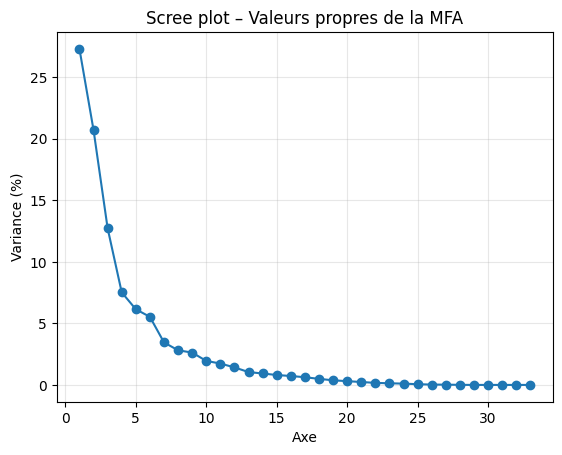

In [52]:
plt.plot(range(1, len(var_axes)+1), var_axes*100, marker="o")
plt.xlabel("Axe")
plt.ylabel("Variance (%)")
plt.title("Scree plot – Valeurs propres de la MFA")
plt.grid(alpha=0.3)
plt.show()

In [53]:
K = 10

# Tronquage des matrices de coordonnées aux K premières dimensions
A_micro = coords_microcine.iloc[:, :K].values
A_res   = coords_resistance.iloc[:, :K].values
A_vir   = coords_virulence.iloc[:, :K].values

In [54]:
def procrustes_test(coords_A, coords_B, n_perm=999, random_state=None):
    """
    Procrustes + test par permutations (version avec scipy.spatial.procrustes).
    """
    rng = np.random.default_rng(random_state)

    # Procrustes observé
    mtx1, mtx2, m2_obs = procrustes(coords_A, coords_B)
    r_obs = np.sqrt(1 - m2_obs)

    # Permutations
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(coords_B)
        _, _, m2_perm = procrustes(coords_A, perm)
        if m2_perm <= m2_obs:
            count += 1

    p_value = (count + 1) / (n_perm + 1)

    return {"m2": m2_obs, "r": r_obs, "p_value": p_value}

In [55]:
# Test de Procrustes
res_mi_re = procrustes_test(A_micro, A_res, n_perm=999, random_state=42)
res_mi_vi = procrustes_test(A_micro, A_vir, n_perm=999, random_state=42)
res_re_vi = procrustes_test(A_res,   A_vir, n_perm=999, random_state=42)

In [56]:
print("Résultats Procrustes (mi-re) :")
print(f"  m²        = {res_mi_re['m2']:.4f}")
print(f"  r         = {res_mi_re['r']:.4f}")
print(f"  p-valeur  = {res_mi_re['p_value']:.4f}")

Résultats Procrustes (mi-re) :
  m²        = 0.8675
  r         = 0.3639
  p-valeur  = 0.0280


In [57]:
print("Résultats Procrustes (mi-vi) :")
print(f"  m²        = {res_mi_vi['m2']:.4f}")
print(f"  r         = {res_mi_vi['r']:.4f}")
print(f"  p-valeur  = {res_mi_vi['p_value']:.4f}")

Résultats Procrustes (mi-vi) :
  m²        = 0.7469
  r         = 0.5030
  p-valeur  = 0.0010


In [58]:
print("Résultats Procrustes (re-vi):")
print(f"  m²        = {res_re_vi['m2']:.4f}")
print(f"  r         = {res_re_vi['r']:.4f}")
print(f"  p-valeur  = {res_re_vi['p_value']:.4f}")

Résultats Procrustes (re-vi):
  m²        = 0.6496
  r         = 0.5919
  p-valeur  = 0.0010


In [59]:
# Calcul des résidus Procrustes (distances par souche)
def procrustes_residuals(coords_A, coords_B, souches):
    mtx1, mtx2, m2 = procrustes(coords_A, coords_B)
    distances = np.sqrt(((mtx1 - mtx2) ** 2).sum(axis=1))
    df_residus = pd.DataFrame({
        "Souche": souches,
        "Distance_Procrustes": distances
    }).sort_values("Distance_Procrustes", ascending=False).reset_index(drop=True)
    return df_residus, m2

In [60]:
# Visualisation 2D avec souches éloignées en surbrillance
def plot_procrustes_highlight(coords_A, coords_B, souches, df_residus, n_highlight=10, title="Procrustes (axes 1-2)"):
    # Alignement Procrustes complet
    mtx1, mtx2, m2 = procrustes(coords_A, coords_B)

    # Sélection des souches les plus éloignées
    top_souches = df_residus.head(n_highlight)["Souche"].tolist()

    plt.figure(figsize=(8,8))
    plt.scatter(mtx1[:,0], mtx1[:,1], c="blue", alpha=0.6, label="Bloc A (référence)")
    plt.scatter(mtx2[:,0], mtx2[:,1], c="red", alpha=0.6, label="Bloc B (aligné)")

    # Tracés des flèches
    for i, souche in enumerate(souches):
        color = "gray"
        lw = 0.7
        alpha = 0.4
        if souche in top_souches:
            color = "#6FA8DC"
            lw = 2.2
            alpha = 0.5
        plt.arrow(mtx1[i,0], mtx1[i,1],
                  mtx2[i,0]-mtx1[i,0],
                  mtx2[i,1]-mtx1[i,1],
                  color=color, alpha=alpha,
                  head_width=0.015, length_includes_head=True)

    # Annotations pour les plus éloignées
    for souche in top_souches:
        i = souches.index(souche)
        plt.text(mtx1[i,0], mtx1[i,1], souche, fontsize=9, color="black", weight="bold")

    plt.axhline(0, color="black", linewidth=0.5)
    plt.axvline(0, color="black", linewidth=0.5)
    plt.title(f"{title}\nErreur globale m² = {m2:.4f}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

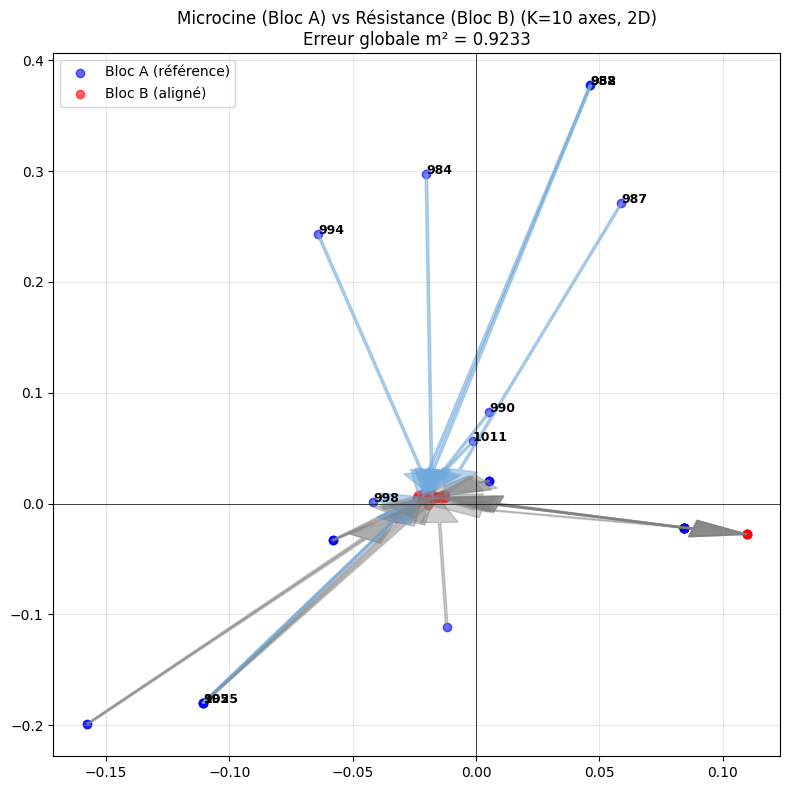

 10 souches les plus éloignées :


,Souche,Distance_Procrustes
0,984,0.319567
1,958,0.292009
2,982,0.291398
3,994,0.270390
4,987,0.266802
5,990,0.240805
6,998,0.196137
7,1011,0.164322
8,1025,0.136107
9,995,0.136107


In [61]:
# Intersection des souches communes
communes = coords_microcine.index.intersection(coords_resistance.index)
souches = communes.tolist()

# Extraction 2D pour l'affichage
coords_A_2D = coords_microcine.loc[communes].iloc[:, :2].values
coords_B_2D = coords_resistance.loc[communes].iloc[:, :2].values

df_residus, m2 = procrustes_residuals(A_micro, A_res, souches)

# Visualisation
K = 10

# Tronquage des matrices de coordonnées aux K premières dimensions
plot_procrustes_highlight(A_micro[:, :2], A_res[:, :2], souches, df_residus,
                          n_highlight=10,
                          title=f"Microcine (Bloc A) vs Résistance (Bloc B) (K={K} axes, 2D)")

# Calcul des résidus sur les K axes complets
print(" 10 souches les plus éloignées :")
display(df_residus.head(10))

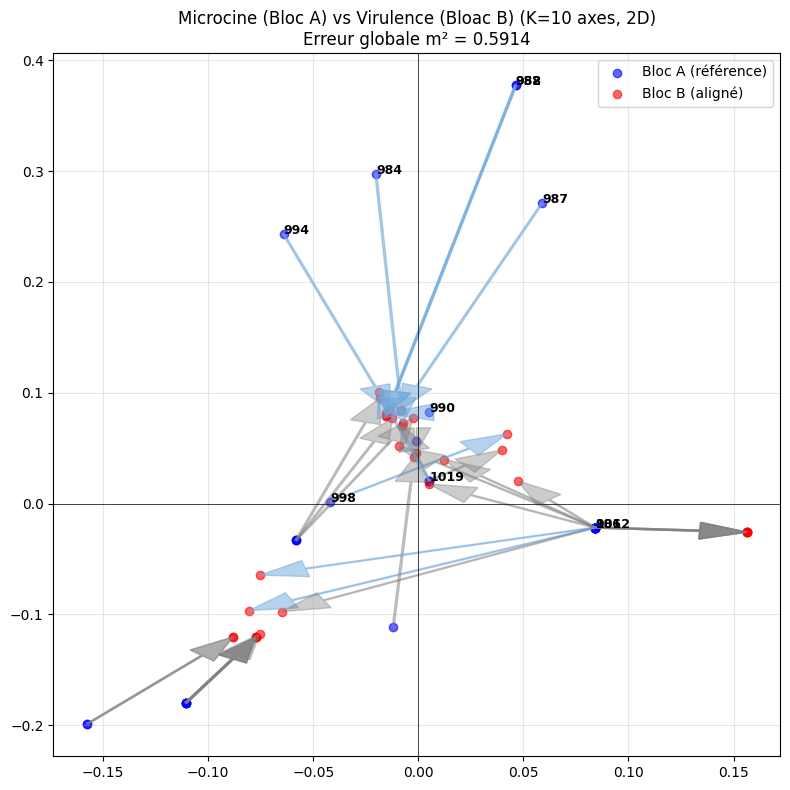

 10 souches les plus éloignées :


,Souche,Distance_Procrustes
0,984,0.292932
1,958,0.254643
2,982,0.254643
3,987,0.236912
4,994,0.234858
5,990,0.229026
6,986,0.187203
7,998,0.185531
8,1012,0.163748
9,1019,0.162959


In [62]:
# Intersection des souches communes
communes = coords_microcine.index.intersection(coords_resistance.index)
souches = communes.tolist()

# Extraction 2D pour l'affichage
#coords_A_2D = coords_microcine.loc[communes].iloc[:, :2].values
#coords_C_2D = coords_virulence.loc[communes].iloc[:, :2].values

df_residus, m2 = procrustes_residuals(A_micro, A_vir, souches)

# Visualisation
K = 10

# Tronquage des matrices de coordonnées aux K premières dimensions
plot_procrustes_highlight(A_micro[:, :2], A_vir[:, :2], souches, df_residus,
                          n_highlight=10,
                          title=f"Microcine (Bloc A) vs Virulence (Bloac B) (K={K} axes, 2D)")

# Calcul des résidus sur les K axes complets
print(" 10 souches les plus éloignées :")
display(df_residus.head(10))

In [63]:
def summarize_procrustes(coords_dict, n_perm=999, random_state=42, top_k=3, K=None):
    """
    Résumé des comparaisons Procrustes entre blocs avec top outliers.

    Args:
        coords_dict : dict {nom_bloc: DataFrame MFA (souches × axes)}
        n_perm      : nb permutations
        random_state: graine aléatoire
        top_k       : nombre de souches les plus discordantes à rapporter
        K           : nombre d'axes à garder pour la comparaison (si None, prend le min commun)

    Returns:
        DataFrame récapitulatif des comparaisons (m², r, p, outliers)
    """
    results = []
    blocs = list(coords_dict.keys())

    for i in range(len(blocs)):
        for j in range(i+1, len(blocs)):
            A, B = blocs[i], blocs[j]
            communes = coords_dict[A].index.intersection(coords_dict[B].index)

            if len(communes) < 3:
                continue

            # Détermination automatique du nombre d'axes communs
            nA = coords_dict[A].shape[1]
            nB = coords_dict[B].shape[1]
            k_use = K if K is not None else min(nA, nB)

            coords_A = coords_dict[A].loc[communes].iloc[:, :k_use].to_numpy()
            coords_B = coords_dict[B].loc[communes].iloc[:, :k_use].to_numpy()
            souches = communes.tolist()

            # Test Procrustes
            res = procrustes_test(coords_A, coords_B, n_perm=n_perm, random_state=random_state)

            # Résidus et outliers
            residus_df, _ = procrustes_residuals(coords_A, coords_B, souches)
            top_outliers = residus_df.head(top_k)["Souche"].tolist()

            results.append({
                "Bloc1": A,
                "Bloc2": B,
                "n_souches": len(communes),
                "n_axes": k_use,
                "m²": round(res["m2"], 4),
                "r": round(res["r"], 4),
                "p_value": res["p_value"],
                "Top_outliers": ", ".join(map(str, top_outliers))
            })

    # DataFrame final
    summary_df = pd.DataFrame(results)
    summary_df = summary_df.sort_values("r", ascending=False).reset_index(drop=True)
    return summary_df

In [64]:
coords_dict = {
    "Microcine": coords_microcine,
    "Résistance": coords_resistance,
    "Virulence": coords_virulence
}

summary_df = summarize_procrustes(coords_dict, n_perm=999, random_state=42, top_k=3, K=10)

print("Résumé Procrustes sur 10 axes :")
display(summary_df)

Résumé Procrustes sur 10 axes :


,Bloc1,Bloc2,n_souches,n_axes,m²,r,p_value,Top_outliers
0,Résistance,Virulence,34,10,0.6496,0.5919,0.001,"1041, 1044, 1033"
1,Microcine,Virulence,34,10,0.7469,0.5030,0.001,"984, 958, 982"
2,Microcine,Résistance,34,10,0.8675,0.3639,0.028,"984, 958, 982"


Ce qu'il faut retenir c'est que chaque famille de gènes (microcine, résistance, virulence) peut être vue comme un point de vue différent sur les mêmes souches.

Vue “microcine” : les souches sont organisées selon les gènes de production/immunité/transport.
Vue “résistance” : selon les gènes d’antibiorésistance.
Vue “virulence” : selon les gènes pathogènes.

Après la MFA, les cartes partielles de ces trois familles montrent la même structure spatiale. ça veut dire que les souches qui sont proches selon les microcines sont aussi proches selon la résistance et selon la virulence.

En d’autres termes, les trois systèmes de gènes racontent la même histoire sur les ressemblances entre souches. autrement dit, elles partagent un profil mixte cohérent combinant ces trois fonctions.

In [65]:
def rv_coefficient(X, Y):
    """Calcule le coefficient RV entre deux matrices (centrées)."""
    Xc = X - X.mean(axis=0)
    Yc = Y - Y.mean(axis=0)
    num = np.trace((Xc @ Xc.T) @ (Yc @ Yc.T))
    den = np.sqrt(np.trace((Xc @ Xc.T) @ (Xc @ Xc.T)) * np.trace((Yc @ Yc.T) @ (Yc @ Yc.T)))
    return num / den if den != 0 else 0

def rv_test(X, Y, n_perm=999, random_state=42):
    """Test de significativité du coefficient RV par permutations."""
    rng = np.random.default_rng(random_state)
    rv_obs = rv_coefficient(X, Y)
    rv_perm = np.zeros(n_perm)

    for i in range(n_perm):
        perm = rng.permutation(Y)
        rv_perm[i] = rv_coefficient(X, perm)

    p_val = (np.sum(rv_perm >= rv_obs) + 1) / (n_perm + 1)
    return rv_obs, p_val

In [66]:
# Même ensemble de souches
communes = set(df_microcine["Souche"]) & set(df_resistance["Souche"]) & set(df_virulence["Souche"])

# Extraction des matrices binaires (sans colonne 'Souche')
X_micro = df_microcine[df_microcine["Souche"].isin(communes)].drop(columns="Souche").to_numpy()
X_res   = df_resistance[df_resistance["Souche"].isin(communes)].drop(columns="Souche").to_numpy()
X_vir   = df_virulence[df_virulence["Souche"].isin(communes)].drop(columns="Souche").to_numpy()

# Calcul et test RV pour chaque paire
rv_mr, p_mr = rv_test(X_micro, X_res)
rv_mv, p_mv = rv_test(X_micro, X_vir)
rv_rv, p_rv = rv_test(X_res, X_vir)

print("Coefficients RV")
print(f"Microcine vs Résistance : RV = {rv_mr:.4f}, p = {p_mr:.4f}")
print(f"Microcine vs Virulence  : RV = {rv_mv:.4f}, p = {p_mv:.4f}")
print(f"Résistance vs Virulence : RV = {rv_rv:.4f}, p = {p_rv:.4f}")

Coefficients RV
Microcine vs Résistance : RV = 0.2296, p = 0.0110
Microcine vs Virulence  : RV = 0.4672, p = 0.0010
Résistance vs Virulence : RV = 0.5335, p = 0.0010


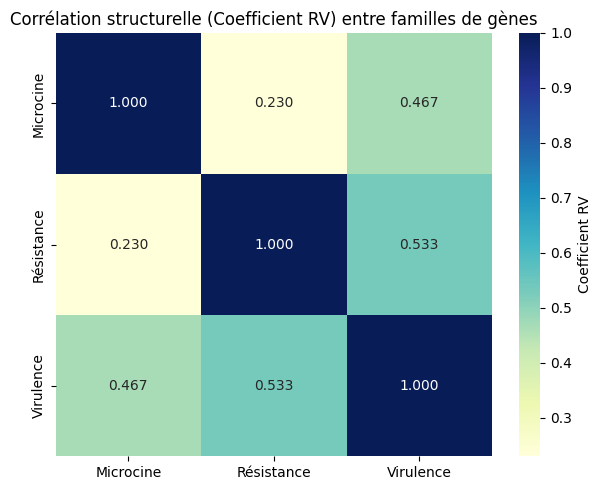

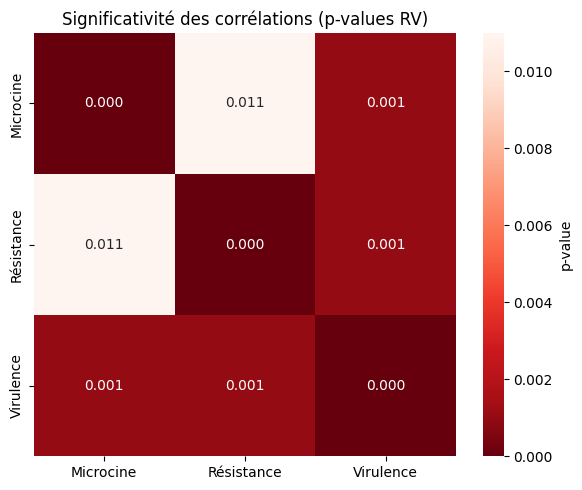

In [67]:
# Dictionnaire pour automatiser les comparaisons
matrices = {"Microcine": X_micro, "Résistance": X_res, "Virulence": X_vir}
blocs = list(matrices.keys())

# Calcul de la matrice RV
rv_matrix = np.zeros((len(blocs), len(blocs)))
p_matrix = np.zeros_like(rv_matrix)

for i in range(len(blocs)):
    for j in range(len(blocs)):
        if i == j:
            rv_matrix[i, j] = 1
            p_matrix[i, j] = 0
        else:
            rv, p = rv_test(matrices[blocs[i]], matrices[blocs[j]], n_perm=999)
            rv_matrix[i, j] = rv
            p_matrix[i, j] = p

# Mise en DataFrame pour affichage
rv_df = pd.DataFrame(rv_matrix, index=blocs, columns=blocs)
pval_df = pd.DataFrame(p_matrix, index=blocs, columns=blocs)

# Heatmap du coefficient RV
plt.figure(figsize=(6,5))
sns.heatmap(rv_df, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Coefficient RV'})
plt.title("Corrélation structurelle (Coefficient RV) entre familles de gènes")
plt.tight_layout()
plt.show()

# Heatmap des p-values (facultative)
plt.figure(figsize=(6,5))
sns.heatmap(pval_df, annot=True, fmt=".3f", cmap="Reds_r", cbar_kws={'label': 'p-value'})
plt.title("Significativité des corrélations (p-values RV)")
plt.tight_layout()
plt.show()

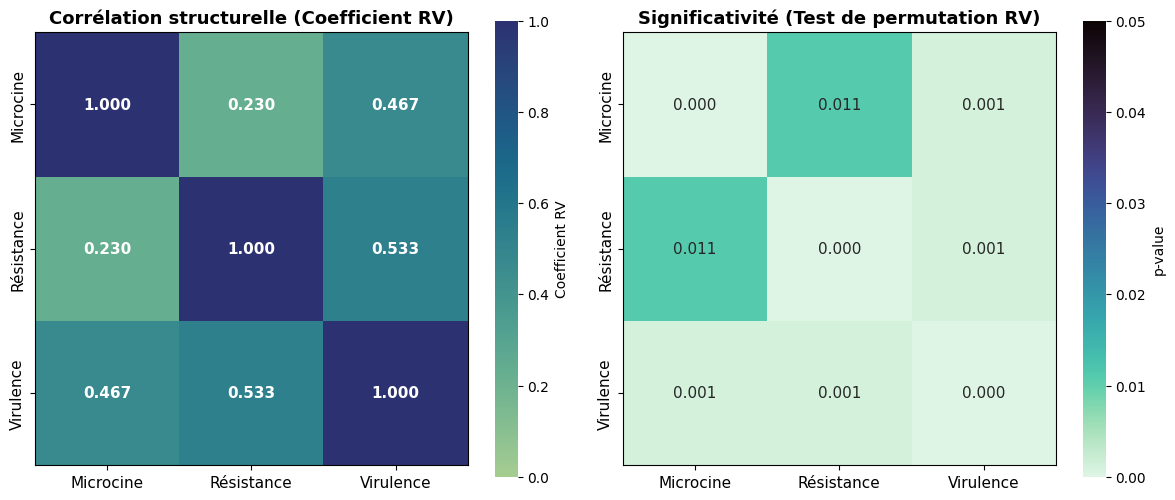

In [68]:
matrices = {"Microcine": X_micro, "Résistance": X_res, "Virulence": X_vir}
blocs = list(matrices.keys())

rv_matrix = np.zeros((len(blocs), len(blocs)))
p_matrix  = np.zeros_like(rv_matrix)

for i in range(len(blocs)):
    for j in range(len(blocs)):
        if i == j:
            rv_matrix[i, j] = 1
            p_matrix[i, j] = 0
        else:
            rv, p = rv_test(matrices[blocs[i]], matrices[blocs[j]], n_perm=999)
            rv_matrix[i, j] = rv
            p_matrix[i, j] = p

rv_df = pd.DataFrame(rv_matrix, index=blocs, columns=blocs)
pval_df = pd.DataFrame(p_matrix, index=blocs, columns=blocs)

# Heatmaps côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Palette pastel harmonieuse
cmap_rv = sns.color_palette("crest", as_cmap=True)
cmap_pv = sns.color_palette("mako_r", as_cmap=True)

# Heatmap RV
sns.heatmap(rv_df, annot=True, fmt=".3f", cmap=cmap_rv,
            vmin=0, vmax=1, square=True, cbar_kws={'label': 'Coefficient RV'}, ax=axes[0],
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title("Corrélation structurelle (Coefficient RV)", fontsize=13, weight="bold")

# Heatmap p-values
sns.heatmap(pval_df, annot=True, fmt=".3f", cmap=cmap_pv,
            vmin=0, vmax=0.05, square=True, cbar_kws={'label': 'p-value'}, ax=axes[1],
            annot_kws={'size': 11})
axes[1].set_title("Significativité (Test de permutation RV)", fontsize=13, weight="bold")

# Ajustements esthétiques
for ax in axes:
    ax.tick_params(axis='both', labelsize=11)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
plt.tight_layout()
plt.show()

« Les coefficients RV confirment les résultats obtenus par les tests de Mantel et Procrustes, avec une similarité faible mais significative entre microcines et résistance (RV = 0,23 ; p = 0,011), modérée entre microcines et virulence (RV = 0,47 ; p = 0,001), et forte entre résistance et virulence (RV = 0,53 ; p = 0,001). Ces valeurs indiquent que les gènes de virulence et de résistance partagent une structure de distribution plus similaire que les microcines avec l’un ou l’autre de ces ensembles. »

Le test RV mesure une similarité globale entre tableaux de données.

Interprétation :

< 0.3 → faible

0.3–0.5 → modérée

> 0.5 → forte.

Ici, virulence et résistance sont les plus corrélés.